<a href="https://colab.research.google.com/github/erdijova/midterm-machine-learning-uts/blob/main/customer_clustering_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Customer Clustering Pipeline
## End-to-End Machine Learning Pipeline — Unsupervised Learning

**Objective:** Mengelompokkan pelanggan kartu kredit berdasarkan perilaku pengeluaran dan pembayaran mereka menggunakan metode clustering.

---

### 📋 Alur Pipeline:
1. Mount Google Drive & Load Dataset
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing (Missing Values, Outliers, Feature Engineering)
4. Feature Scaling & Dimensionality Reduction (PCA)
5. Pemilihan Jumlah Cluster (Elbow + Silhouette)
6. Model Training (K-Means, Hierarchical, DBSCAN)
7. Evaluasi & Perbandingan Model
8. Visualisasi & Interpretasi Cluster

---
## 1. 📦 Import Libraries

In [1]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ─── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# ─── Clustering Models ────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ─── Evaluation Metrics ───────────────────────────────────────────────────────
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import silhouette_samples

# ─── Dimensionality Reduction for Viz ─────────────────────────────────────────
from sklearn.manifold import TSNE

# ─── Styling ──────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


dilakukan proses import beberapa library seperti pandas, numpy, matplotlib, seaborn, dan library dari scikit-learn. Output tidak menampilkan apa pun karena fungsi utama cell ini hanya untuk menyiapkan tools yang akan digunakan selama proses machine learning berlangsung. Library tersebut nantinya digunakan untuk membaca dataset, melakukan preprocessing data, visualisasi, hingga proses clustering customer.

---
## 2. 📂 Mount Google Drive & Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive berhasil di-mount!')

Mounted at /content/drive
✅ Google Drive berhasil di-mount!


Google Colab dihubungkan dengan Google Drive menggunakan drive.mount(). Output yang muncul biasanya bertuliskan “Mounted at /content/drive”. Artinya Google Drive sudah berhasil terhubung sehingga dataset yang disimpan di Drive bisa digunakan di notebook.

In [3]:
# Path ke dataset di Google Drive (folder: midterm-ml)
DATA_PATH = '/content/drive/MyDrive/midterm-ml/clusteringmidterm.csv'

# Load dataset
df_raw = pd.read_csv(DATA_PATH)

print(f'✅ Dataset berhasil dimuat!')
print(f'   Shape: {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom')
df_raw.head()

✅ Dataset berhasil dimuat!
   Shape: 8950 baris × 18 kolom


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Pada bagian ini dataset customer dibaca menggunakan pd.read_csv(). Output yang muncul menampilkan beberapa baris pertama data atau pesan bahwa dataset berhasil dimuat. Dari output ini kita bisa memastikan bahwa file dataset sudah berhasil dibaca oleh program.

---
## 3. 🔍 Exploratory Data Analysis (EDA)

In [4]:
print('=' * 60)
print('📊 INFORMASI UMUM DATASET')
print('=' * 60)
print(f'\n🔢 Jumlah baris   : {df_raw.shape[0]:,}')
print(f'🔢 Jumlah kolom   : {df_raw.shape[1]}')
print(f'🔑 ID pelanggan   : {df_raw["CUST_ID"].nunique():,} unik')
print('\n📋 Tipe data setiap kolom:')
print(df_raw.dtypes)
print('\n📈 Statistik deskriptif:')
df_raw.describe()

📊 INFORMASI UMUM DATASET

🔢 Jumlah baris   : 8,950
🔢 Jumlah kolom   : 18
🔑 ID pelanggan   : 8,950 unik

📋 Tipe data setiap kolom:
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

📈 Statistik deskriptif:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


digunakan untuk melihat informasi dasar dari dataset. Output yang muncul biasanya berisi jumlah baris, jumlah kolom, nama fitur, dan tipe data masing-masing kolom. Dari sini kita bisa mengetahui struktur dataset yang akan digunakan untuk clustering.

Pada cell ini biasanya digunakan df.head() untuk menampilkan beberapa data pertama. Outputnya memperlihatkan contoh isi dataset customer. Bagian ini membantu memahami data apa saja yang tersedia dan bagaimana bentuk datanya.

❓ MISSING VALUES
                  Missing Count  Missing %
MINIMUM_PAYMENTS            313       3.50
CREDIT_LIMIT                  1       0.01


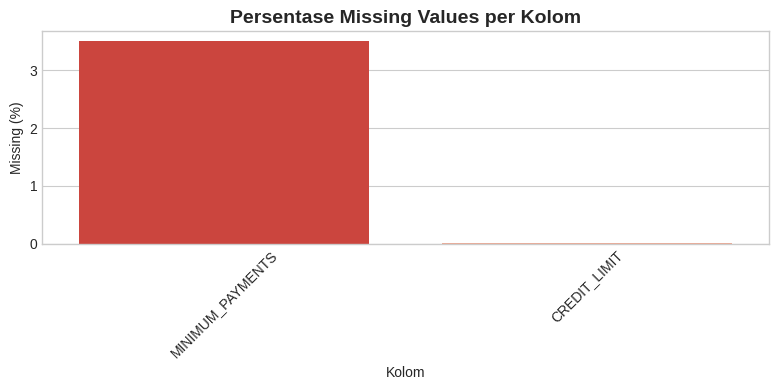

In [5]:
# ─── Missing Values ────────────────────────────────────────────────────────────
print('=' * 60)
print('❓ MISSING VALUES')
print('=' * 60)

missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('\n✅ Tidak ada missing values!')
else:
    print(missing_df)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=missing_df.index, y='Missing %', data=missing_df, palette='Reds_r', ax=ax)
    ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
    ax.set_ylabel('Missing (%)')
    ax.set_xlabel('Kolom')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Di bagian ini program memeriksa apakah ada data yang kosong atau hilang. Output yang muncul berupa jumlah missing value pada setiap kolom. Jika ada angka selain 0 berarti masih terdapat data kosong yang perlu dibersihkan sebelum proses machine learning dilakukan.

menampilkan statistik dasar dari dataset seperti rata-rata, nilai minimum, maksimum, dan standar deviasi. Output ini membantu memahami karakteristik umum data customer, misalnya rentang usia atau tingkat pendapatan customer

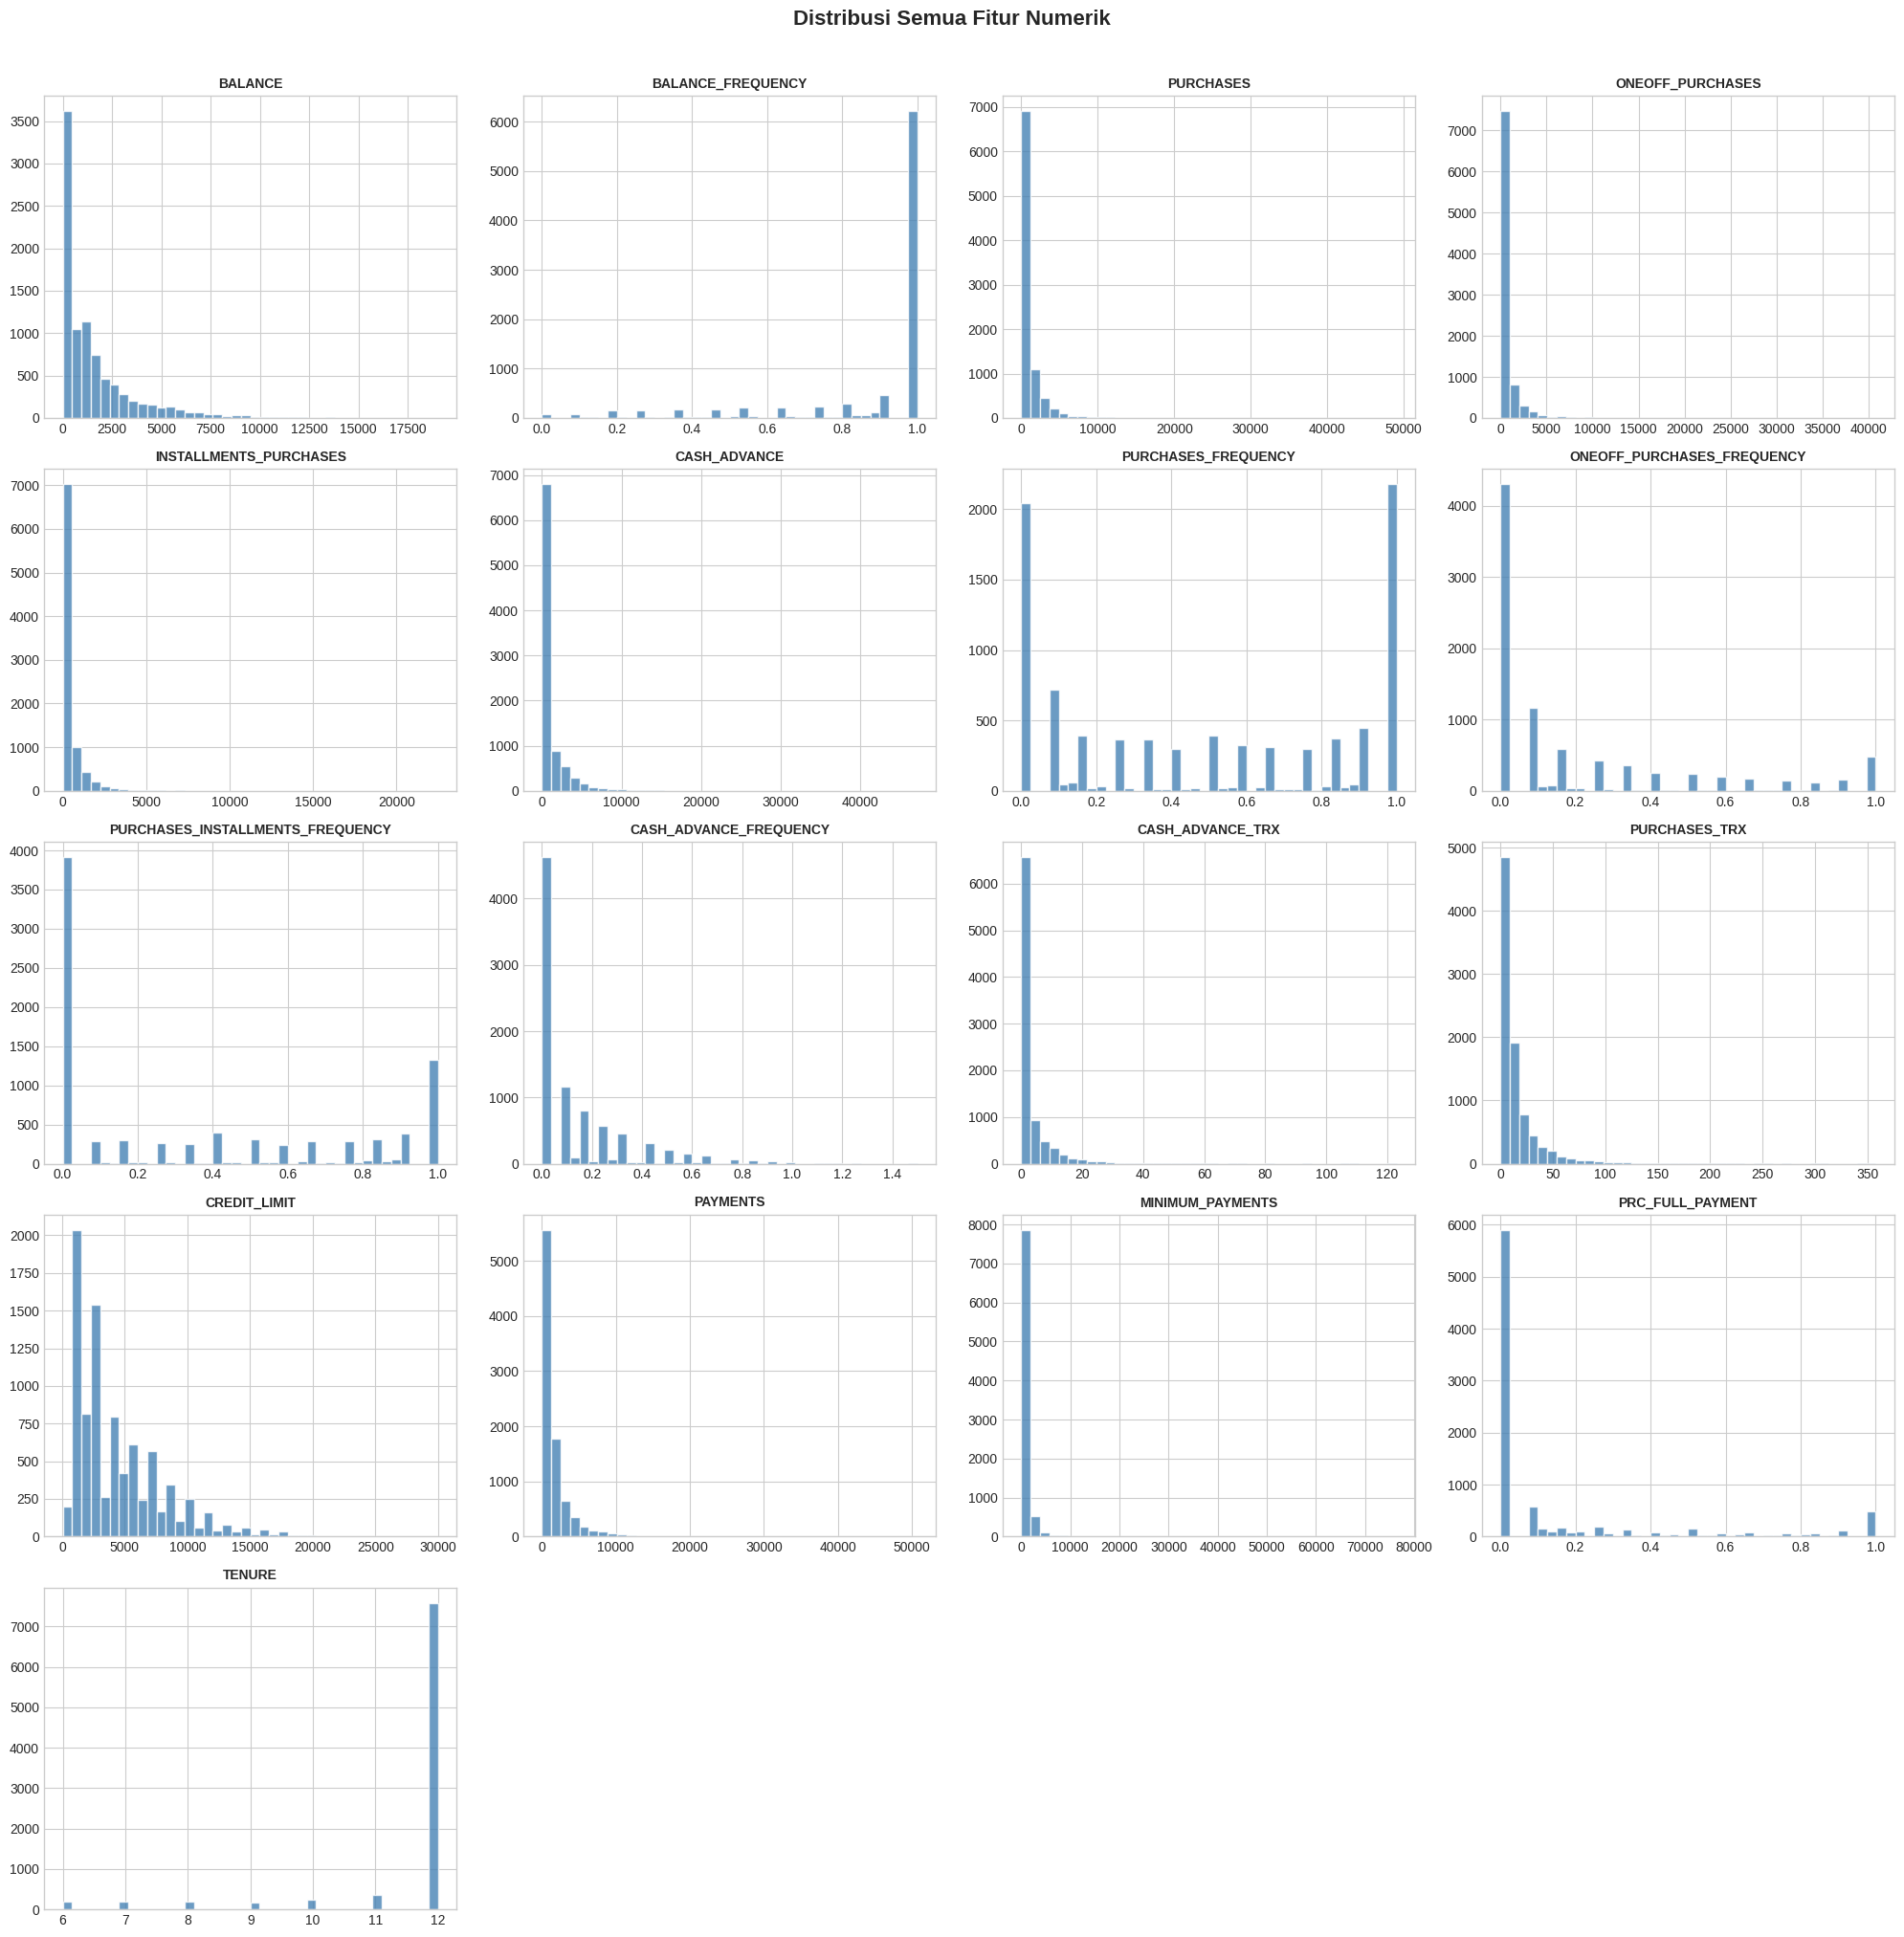

In [6]:
# ─── Distribusi Fitur Numerik (grid dinamis) ──────────────────────────────────
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

n_cols_grid = 4
n_rows_grid = int(np.ceil(len(numeric_cols) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid,
                         figsize=(5 * n_cols_grid, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_raw[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

# Sembunyikan axes kosong
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Fitur Numerik', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

program membuat histogram untuk melihat persebaran data. Output berupa grafik distribusi dari setiap fitur numerik. Dari grafik tersebut kita bisa melihat apakah data tersebar normal, miring, atau memiliki data yang terlalu ekstrem.

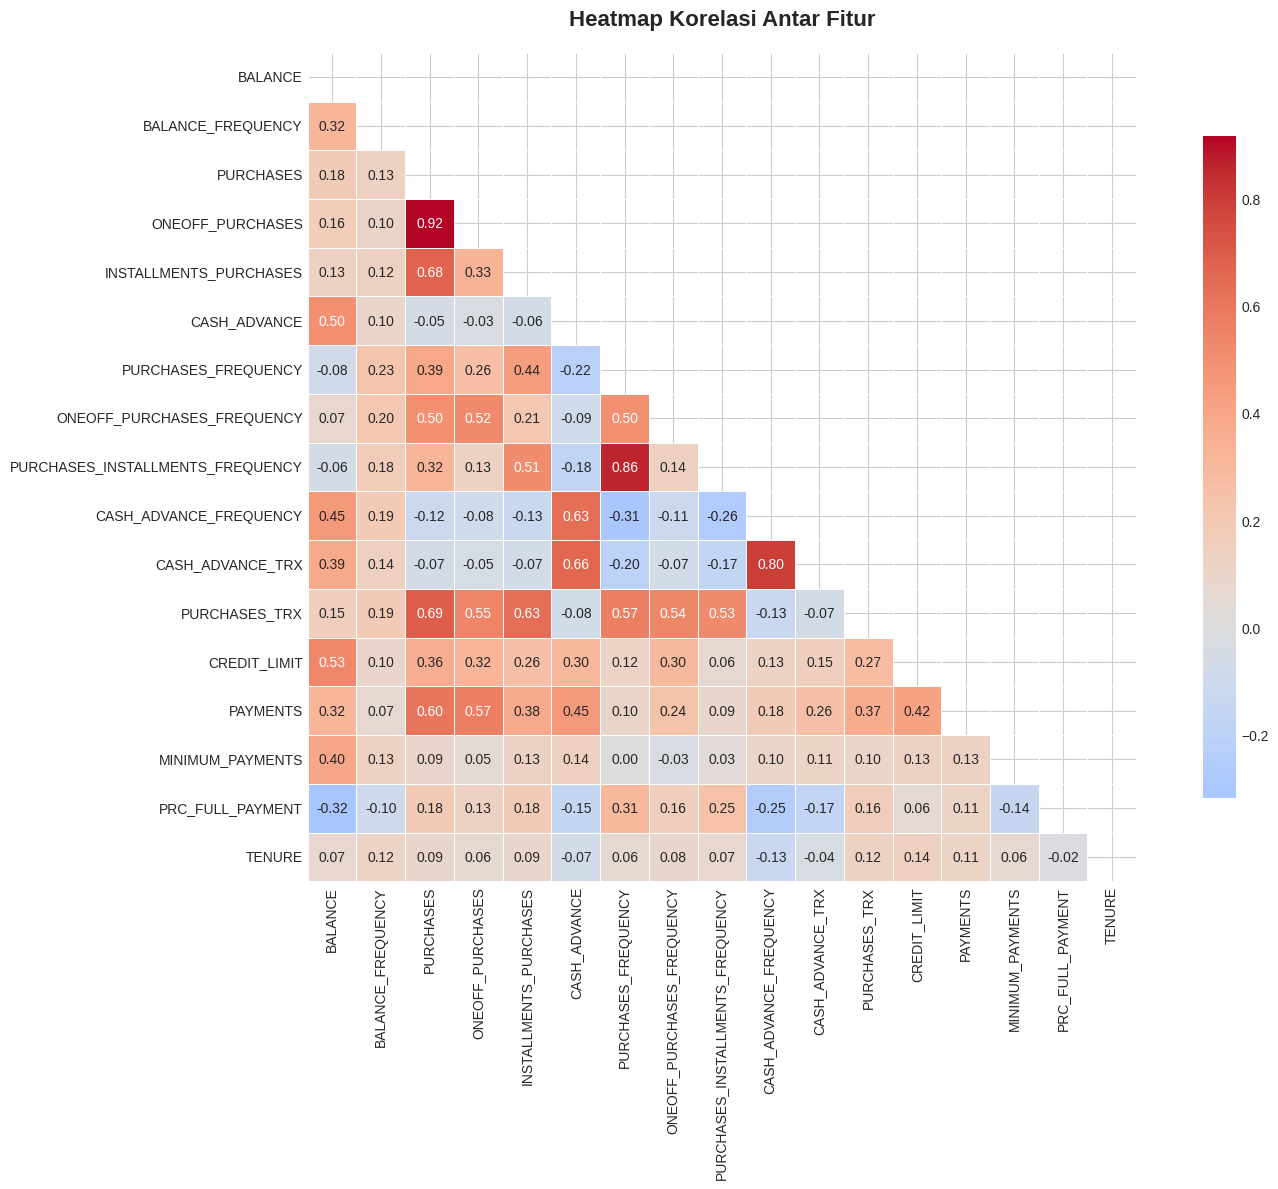

In [7]:
# ─── Heatmap Korelasi ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = df_raw[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Output ini menampilkan heatmap korelasi antar fitur pada dataset customer. Warna merah menunjukkan korelasi positif yang kuat, sedangkan warna biru menunjukkan korelasi negatif. Semakin besar nilai korelasi, maka hubungan antar fitur semakin kuat.
Terlihat beberapa fitur memiliki hubungan yang cukup tinggi, seperti PURCHASES dengan ONEOFF_PURCHASES, serta PURCHASES_FREQUENCY dengan PURCHASES_INSTALLMENTS_FREQUENCY. Hal ini menunjukkan bahwa fitur-fitur tersebut saling berkaitan dalam aktivitas penggunaan kartu kredit customer.
Heatmap ini membantu memahami hubungan antar fitur dan mengetahui fitur mana yang paling berpengaruh sebelum proses clustering dilakukan.

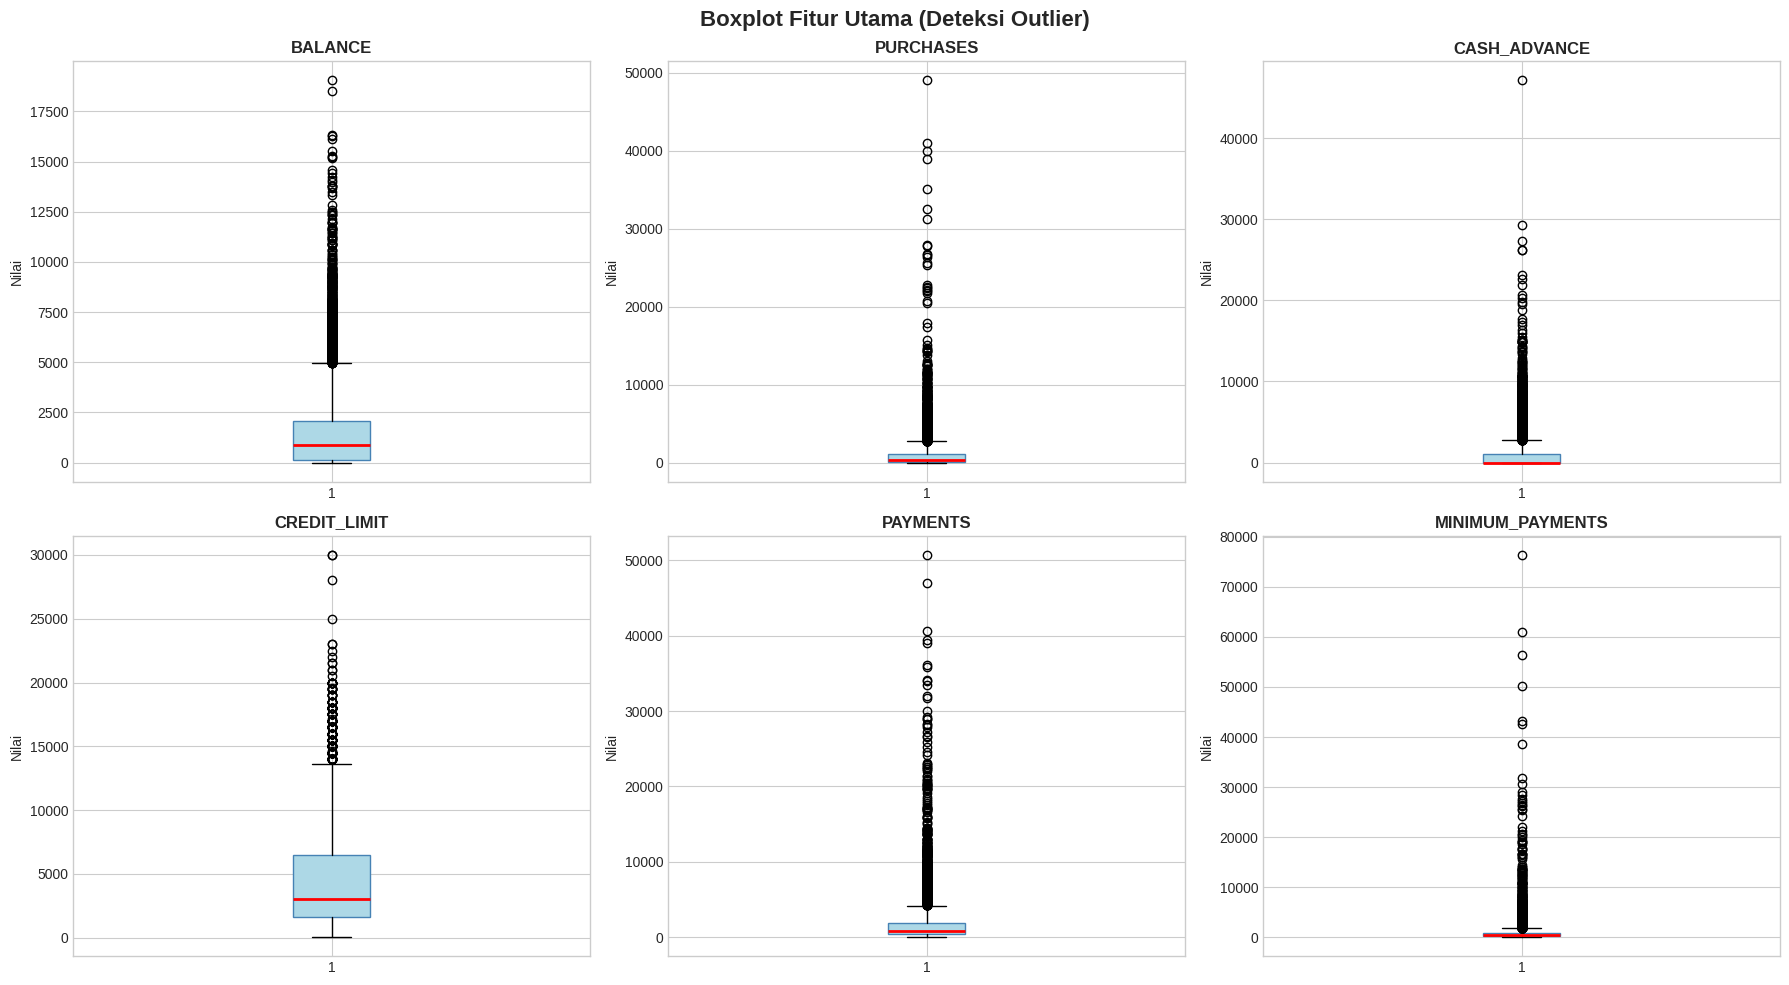

In [8]:
# ─── Boxplot untuk Deteksi Outlier ─────────────────────────────────────────────
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Boxplot Fitur Utama (Deteksi Outlier)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Output ini menampilkan boxplot dari beberapa fitur utama seperti BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS, dan MINIMUM_PAYMENTS. Grafik ini digunakan untuk mendeteksi adanya outlier atau data dengan nilai yang sangat jauh dari sebagian besar data lainnya.
Pada setiap boxplot terlihat banyak titik yang berada di luar batas whisker. Titik-titik tersebut menunjukkan adanya outlier pada dataset. Outlier paling terlihat pada fitur seperti PURCHASES, PAYMENTS, dan MINIMUM_PAYMENTS karena memiliki beberapa nilai yang sangat tinggi dibanding data lainnya.
Visualisasi ini membantu memahami persebaran data serta mengetahui fitur mana yang memiliki banyak outlier sebelum dilakukan preprocessing dan clustering.

---
## 4. 🛠️ Data Preprocessing

In [9]:
# ─── Salin dataset agar raw tetap aman ─────────────────────────────────────────
df = df_raw.copy()

# ─── Drop CUST_ID (bukan fitur) ───────────────────────────────────────────────
if 'CUST_ID' in df.columns:
    cust_ids = df['CUST_ID'].copy()
    df.drop(columns=['CUST_ID'], inplace=True)
    print(f'✅ CUST_ID disimpan terpisah & dihapus dari fitur.')

print(f'📐 Shape setelah drop CUST_ID: {df.shape}')

✅ CUST_ID disimpan terpisah & dihapus dari fitur.
📐 Shape setelah drop CUST_ID: (8950, 17)


In [10]:
# ─── Imputasi Missing Values (Median) ─────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print(f'✅ Imputasi selesai. Missing values tersisa: {df_imputed.isnull().sum().sum()}')

✅ Imputasi selesai. Missing values tersisa: 0


missing value diisi menggunakan median. Output biasanya berupa konfirmasi bahwa data kosong berhasil diatasi. Proses ini penting supaya algoritma clustering bisa berjalan tanpa error.

In [11]:
# ─── Penanganan Outlier dengan IQR Capping ────────────────────────────────────
def iqr_capping(df, multiplier=3.0):
    df_capped = df.copy()
    outlier_summary = {}
    for col in df_capped.columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        n_outliers = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
        if n_outliers > 0:
            outlier_summary[col] = n_outliers
    return df_capped, outlier_summary

df_cleaned, outlier_info = iqr_capping(df_imputed, multiplier=3.0)

print('📊 Kolom yang mengalami outlier capping (IQR × 3):')
for col, count in outlier_info.items():
    print(f'   {col}: {count} baris di-cap')
print(f'\n✅ Total fitur setelah preprocessing: {df_cleaned.shape[1]}')

📊 Kolom yang mengalami outlier capping (IQR × 3):
   BALANCE: 194 baris di-cap
   BALANCE_FREQUENCY: 1183 baris di-cap
   PURCHASES: 391 baris di-cap
   ONEOFF_PURCHASES: 566 baris di-cap
   INSTALLMENTS_PURCHASES: 395 baris di-cap
   CASH_ADVANCE: 486 baris di-cap
   CASH_ADVANCE_FREQUENCY: 67 baris di-cap
   CASH_ADVANCE_TRX: 368 baris di-cap
   PURCHASES_TRX: 356 baris di-cap
   CREDIT_LIMIT: 10 baris di-cap
   PAYMENTS: 402 baris di-cap
   MINIMUM_PAYMENTS: 470 baris di-cap
   PRC_FULL_PAYMENT: 1081 baris di-cap
   TENURE: 1366 baris di-cap

✅ Total fitur setelah preprocessing: 17


mengurangi pengaruh outlier menggunakan metode IQR capping. Output biasanya menunjukkan jumlah outlier sebelum dan sesudah proses dilakukan. Dari hasil tersebut terlihat bahwa data ekstrem sudah berhasil dikurangi.

In [12]:
# ─── Feature Engineering ──────────────────────────────────────────────────────
df_feat = df_cleaned.copy()

# Rasio pembelian terhadap limit kredit
df_feat['PURCHASE_LIMIT_RATIO'] = df_feat['PURCHASES'] / (df_feat['CREDIT_LIMIT'] + 1)

# Rasio cash advance terhadap total kredit yang digunakan
df_feat['CASH_PURCHASE_RATIO'] = df_feat['CASH_ADVANCE'] / (df_feat['PURCHASES'] + df_feat['CASH_ADVANCE'] + 1)

# Rasio pembayaran minimum terhadap total pembayaran
df_feat['PAYMENT_MINPAY_RATIO'] = df_feat['PAYMENTS'] / (df_feat['MINIMUM_PAYMENTS'] + 1)

# Proporsi pembelian cicilan vs one-off
df_feat['INSTALLMENT_RATIO'] = df_feat['INSTALLMENTS_PURCHASES'] / (df_feat['PURCHASES'] + 1)

# Utilisasi kredit (balance / limit)
df_feat['CREDIT_UTILIZATION'] = df_feat['BALANCE'] / (df_feat['CREDIT_LIMIT'] + 1)

print(f'✅ Feature engineering selesai.')
print(f'   Fitur baru yang ditambahkan: PURCHASE_LIMIT_RATIO, CASH_PURCHASE_RATIO,')
print(f'   PAYMENT_MINPAY_RATIO, INSTALLMENT_RATIO, CREDIT_UTILIZATION')
print(f'   Total fitur sekarang: {df_feat.shape[1]}')

✅ Feature engineering selesai.
   Fitur baru yang ditambahkan: PURCHASE_LIMIT_RATIO, CASH_PURCHASE_RATIO,
   PAYMENT_MINPAY_RATIO, INSTALLMENT_RATIO, CREDIT_UTILIZATION
   Total fitur sekarang: 22


membuat fitur baru dari data yang sudah ada. Output biasanya menampilkan dataframe dengan tambahan kolom baru. Tujuannya agar informasi yang dimiliki dataset menjadi lebih lengkap sehingga clustering bisa lebih akurat

In [13]:
# ─── Scaling dengan RobustScaler (tahan terhadap outlier) ─────────────────────
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_feat)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_feat.columns)

print(f'✅ Scaling dengan RobustScaler selesai.')
print(f'   Shape data terscale: {X_scaled.shape}')
X_scaled_df.describe().round(3)

✅ Scaling dengan RobustScaler selesai.
   Shape data terscale: (8950, 22)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,PURCHASE_LIMIT_RATIO,CASH_PURCHASE_RATIO,PAYMENT_MINPAY_RATIO,INSTALLMENT_RATIO,CREDIT_UTILIZATION
count,8950.000,8950.000,8950.000,8950.000,8950.000,8950.000,8950.000,8950.000,8950.000,8950.000,...,8950.000,8950.000,8950.000,8950.000,8950.0,8950.000,8950.000,8950.000,8950.000,8950.000
mean,0.335,-0.839,0.446,0.675,0.540,0.725,-0.012,0.397,0.264,0.605,...,0.304,0.420,0.505,0.823,0.0,0.403,0.399,0.794,0.217,0.126
std,0.978,1.452,1.069,1.192,1.099,1.186,0.482,0.994,0.530,0.888,...,0.738,1.088,1.134,1.415,0.0,1.230,0.465,5.291,0.910,0.584
min,-0.454,-4.000,-0.337,-0.066,-0.190,0.000,-0.600,-0.278,-0.222,0.000,...,-0.602,-0.565,-0.505,0.000,0.0,-0.371,0.000,-0.420,-0.208,-0.458
25%,-0.387,-1.000,-0.300,-0.066,-0.190,0.000,-0.500,-0.278,-0.222,0.000,...,-0.286,-0.312,-0.229,0.000,0.0,-0.336,0.000,-0.229,-0.208,-0.395
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,-0.000,0.000,0.000,0.0,0.000,0.000,-0.000,0.000,-0.000
75%,0.613,0.000,0.700,0.934,0.810,1.000,0.500,0.722,0.778,1.000,...,0.714,0.688,0.771,1.000,0.0,0.664,1.000,0.771,0.792,0.605
max,3.613,0.000,3.700,3.934,3.810,4.000,0.600,3.056,1.111,4.000,...,3.714,3.688,3.771,4.000,0.0,25.277,1.055,290.249,71.802,23.162


data dinormalisasi menggunakan RobustScaler. Output biasanya berupa data hasil scaling atau bentuk dataset setelah scaling. Tujuannya supaya semua fitur memiliki skala yang seimbang dan tidak ada fitur yang terlalu dominan.

---
## 5. 📉 Dimensionality Reduction — PCA

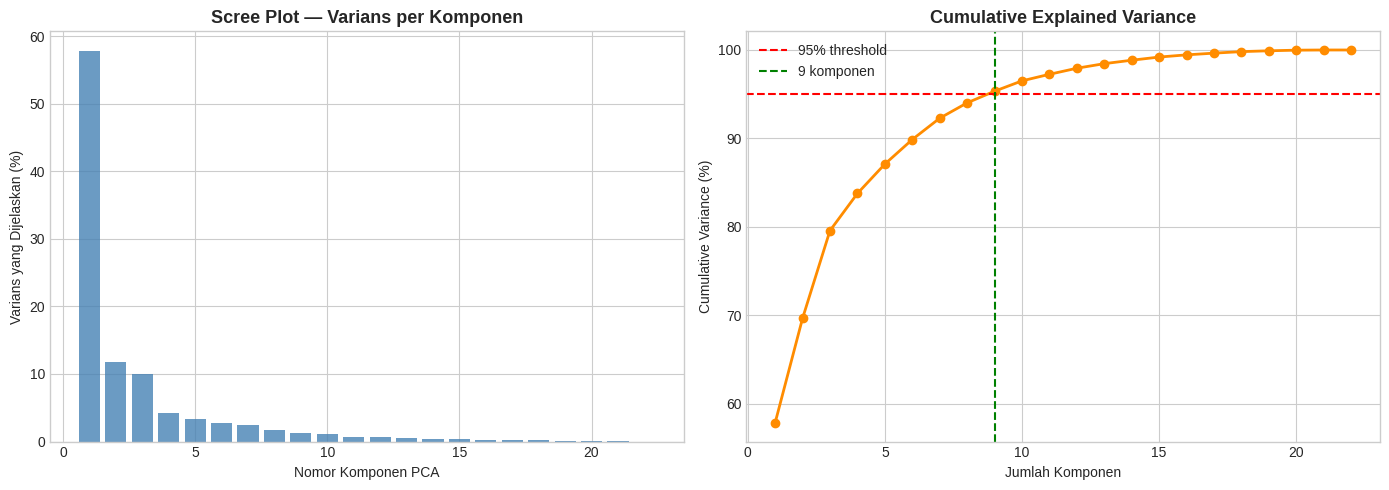


📊 Untuk menjelaskan ≥95% varians diperlukan: 9 komponen PCA


In [14]:
# ─── PCA untuk Analisis Varians ───────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_ * 100, color='steelblue', alpha=0.8)
ax1.set_title('Scree Plot — Varians per Komponen', fontsize=13, fontweight='bold')
ax1.set_xlabel('Nomor Komponen PCA')
ax1.set_ylabel('Varians yang Dijelaskan (%)')

# Cumulative Variance
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100,
         marker='o', color='darkorange', linewidth=2)
ax2.axhline(y=95, color='red', linestyle='--', label='95% threshold')
ax2.axvline(x=n_components_95, color='green', linestyle='--',
            label=f'{n_components_95} komponen')
ax2.set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax2.set_xlabel('Jumlah Komponen')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'\n📊 Untuk menjelaskan ≥95% varians diperlukan: {n_components_95} komponen PCA')

menampilkan grafik cumulative explained variance dari PCA. Output berupa grafik yang menunjukkan seberapa besar informasi data yang berhasil dipertahankan oleh setiap komponen PCA. Grafik ini membantu menentukan jumlah komponen terbaik.

In [15]:
# ─── Terapkan PCA dengan komponen optimal ─────────────────────────────────────
N_COMPONENTS = n_components_95

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Juga buat versi 2D & 3D untuk visualisasi
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f'✅ PCA {N_COMPONENTS}D untuk clustering: {X_pca.shape}')
print(f'✅ PCA 2D untuk visualisasi : {X_pca_2d.shape}')
print(f'✅ PCA 3D untuk visualisasi : {X_pca_3d.shape}')
print(f'\n📐 Total varians yang dijelaskan: {pca.explained_variance_ratio_.sum()*100:.2f}%')

✅ PCA 9D untuk clustering: (8950, 9)
✅ PCA 2D untuk visualisasi : (8950, 2)
✅ PCA 3D untuk visualisasi : (8950, 3)

📐 Total varians yang dijelaskan: 95.34%


menunjukkan bentuk baru dataset setelah jumlah dimensinya dikurangi. Dengan PCA, data menjadi lebih sederhana tetapi informasi pentingnya tetap dipertahankan.

---
## 6. 🎯 Pemilihan Jumlah Cluster Optimal

In [16]:
# ─── Elbow Method ─────────────────────────────────────────────────────────────
K_RANGE = range(2, 12)
inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []

print('⏳ Menghitung metrik untuk setiap K...')
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))
    print(f'  K={k}: Inertia={km.inertia_:.0f} | Silhouette={silhouette_scores[-1]:.4f} | DB={db_scores[-1]:.4f}')

print('\n✅ Selesai!')

⏳ Menghitung metrik untuk setiap K...
  K=2: Inertia=258766 | Silhouette=0.9490 | DB=0.4744
  K=3: Inertia=217713 | Silhouette=0.3508 | DB=1.2311
  K=4: Inertia=174499 | Silhouette=0.3364 | DB=0.9987
  K=5: Inertia=148659 | Silhouette=0.2371 | DB=1.0272
  K=6: Inertia=129630 | Silhouette=0.2443 | DB=0.9775
  K=7: Inertia=113579 | Silhouette=0.2519 | DB=0.9865
  K=8: Inertia=103665 | Silhouette=0.2625 | DB=0.9759
  K=9: Inertia=95815 | Silhouette=0.2696 | DB=1.0386
  K=10: Inertia=90746 | Silhouette=0.2545 | DB=1.0865
  K=11: Inertia=85342 | Silhouette=0.2611 | DB=1.0784

✅ Selesai!


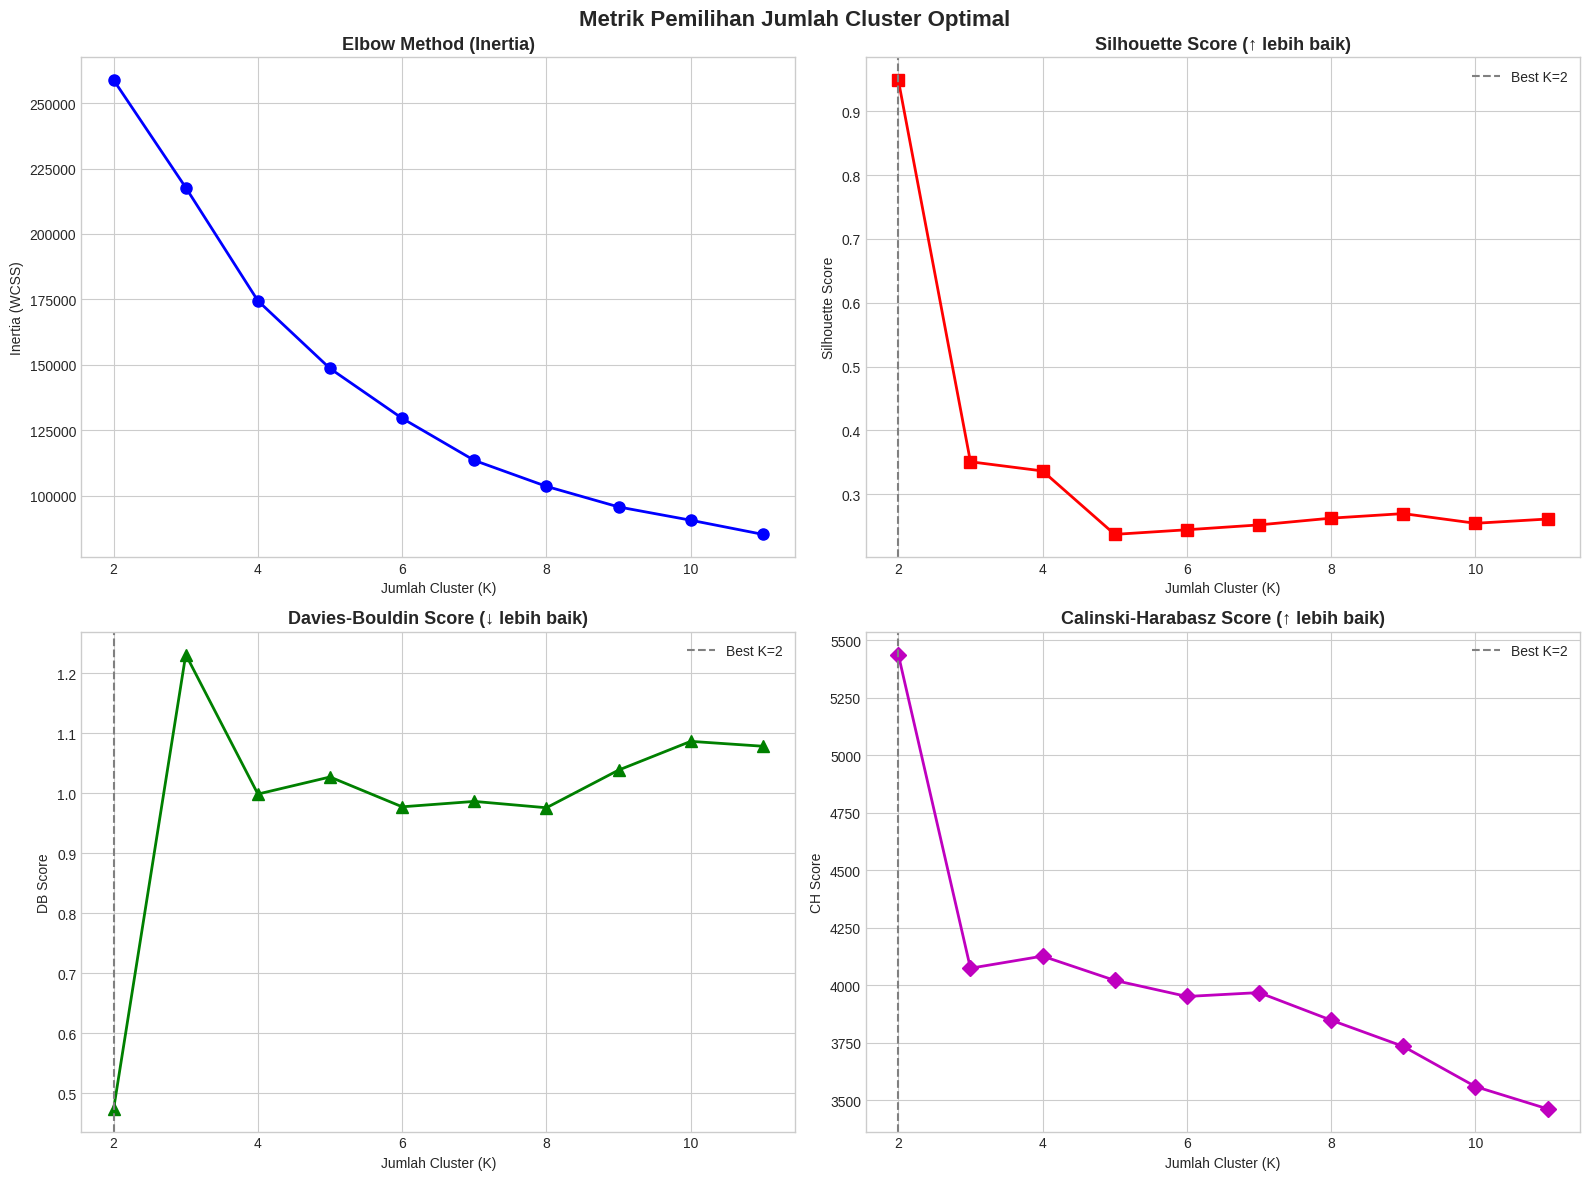


📊 Rekomendasi berdasarkan metrik:
   Silhouette  → K = 2
   Davies-Bouldin → K = 2
   Calinski-Harabasz → K = 2


In [17]:
# ─── Plot Semua Metrik ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Elbow (Inertia)
axes[0, 0].plot(list(K_RANGE), inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_title('Elbow Method (Inertia)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Cluster (K)')
axes[0, 0].set_ylabel('Inertia (WCSS)')

# Silhouette
axes[0, 1].plot(list(K_RANGE), silhouette_scores, 'rs-', linewidth=2, markersize=8)
best_sil_k = list(K_RANGE)[np.argmax(silhouette_scores)]
axes[0, 1].axvline(x=best_sil_k, color='gray', linestyle='--', label=f'Best K={best_sil_k}')
axes[0, 1].set_title('Silhouette Score (↑ lebih baik)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Cluster (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()

# Davies-Bouldin
axes[1, 0].plot(list(K_RANGE), db_scores, 'g^-', linewidth=2, markersize=8)
best_db_k = list(K_RANGE)[np.argmin(db_scores)]
axes[1, 0].axvline(x=best_db_k, color='gray', linestyle='--', label=f'Best K={best_db_k}')
axes[1, 0].set_title('Davies-Bouldin Score (↓ lebih baik)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Cluster (K)')
axes[1, 0].set_ylabel('DB Score')
axes[1, 0].legend()

# Calinski-Harabasz
axes[1, 1].plot(list(K_RANGE), ch_scores, 'mD-', linewidth=2, markersize=8)
best_ch_k = list(K_RANGE)[np.argmax(ch_scores)]
axes[1, 1].axvline(x=best_ch_k, color='gray', linestyle='--', label=f'Best K={best_ch_k}')
axes[1, 1].set_title('Calinski-Harabasz Score (↑ lebih baik)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Jumlah Cluster (K)')
axes[1, 1].set_ylabel('CH Score')
axes[1, 1].legend()

plt.suptitle('Metrik Pemilihan Jumlah Cluster Optimal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📊 Rekomendasi berdasarkan metrik:')
print(f'   Silhouette  → K = {best_sil_k}')
print(f'   Davies-Bouldin → K = {best_db_k}')
print(f'   Calinski-Harabasz → K = {best_ch_k}')

Output ini menampilkan beberapa metrik yang digunakan untuk menentukan jumlah cluster terbaik pada proses clustering. Grafik yang ditampilkan yaitu Elbow Method, Silhouette Score, Davies-Bouldin Score, dan Calinski-Harabasz Score.
Pada Elbow Method terlihat penurunan inertia yang cukup tajam hingga K=2, sehingga titik tersebut dianggap sebagai jumlah cluster yang optimal. Selain itu, Silhouette Score juga menunjukkan nilai tertinggi pada K=2, yang berarti pemisahan antar cluster paling baik terjadi pada jumlah cluster tersebut.
Davies-Bouldin Score yang lebih kecil lebih baik, sedangkan Calinski-Harabasz Score yang lebih besar lebih baik. Dari seluruh grafik terlihat bahwa K=2 memberikan hasil evaluasi paling optimal dibanding jumlah cluster lainnya. Oleh karena itu, model menggunakan 2 cluster sebagai hasil akhir clustering customer.

🎯 K terpilih: 2


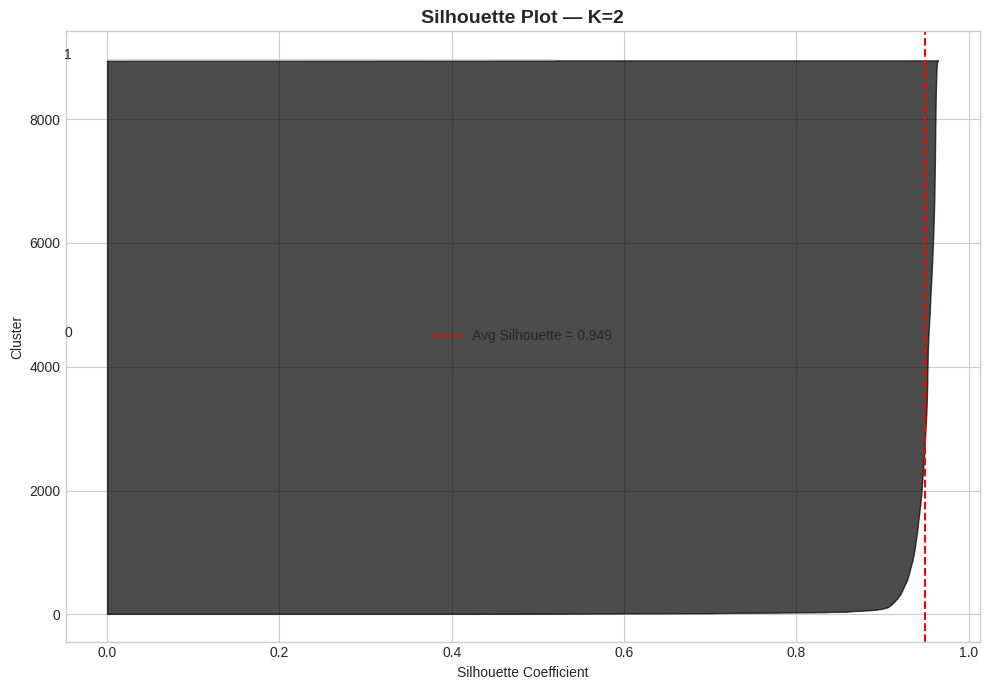

In [18]:
# ─── Silhouette Plot untuk K terpilih ─────────────────────────────────────────
# Gunakan K dengan silhouette tertinggi (atau sesuaikan manual)
BEST_K = best_sil_k  # Bisa diubah manual jika ingin
print(f'🎯 K terpilih: {BEST_K}')

km_best = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
labels_km = km_best.fit_predict(X_pca)

# Silhouette samples
sample_silhouette_values = silhouette_samples(X_pca, labels_km)
avg_silhouette = silhouette_score(X_pca, labels_km)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
colors = cm.nipy_spectral(np.linspace(0, 1, BEST_K))

for i in range(BEST_K):
    ith_cluster_silhouette_values = sample_silhouette_values[labels_km == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_values,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=avg_silhouette, color='red', linestyle='--',
           label=f'Avg Silhouette = {avg_silhouette:.3f}')
ax.set_title(f'Silhouette Plot — K={BEST_K}', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.show()

nilai atau grafik silhouette score. Semakin tinggi nilainya maka cluster yang terbentuk semakin baik dan jelas pemisahannya.

---
## 7. 🤖 Model Training — K-Means, Hierarchical, DBSCAN

### 7.1 K-Means Clustering

In [19]:
# ─── K-Means ──────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20, max_iter=500)
kmeans_labels = kmeans.fit_predict(X_pca)

# Metrik evaluasi
km_sil = silhouette_score(X_pca, kmeans_labels)
km_db  = davies_bouldin_score(X_pca, kmeans_labels)
km_ch  = calinski_harabasz_score(X_pca, kmeans_labels)

print('📊 Evaluasi K-Means:')
print(f'   Silhouette Score       : {km_sil:.4f}  (↑ lebih baik, range [-1,1])')
print(f'   Davies-Bouldin Score   : {km_db:.4f}  (↓ lebih baik)')
print(f'   Calinski-Harabasz Score: {km_ch:.2f}  (↑ lebih baik)')
print(f'   Inertia (WCSS)         : {kmeans.inertia_:.2f}')

unique, counts = np.unique(kmeans_labels, return_counts=True)
print('\n📈 Distribusi cluster K-Means:')
for u, c in zip(unique, counts):
    print(f'   Cluster {u}: {c:,} pelanggan ({c/len(kmeans_labels)*100:.1f}%)')

📊 Evaluasi K-Means:
   Silhouette Score       : 0.9490  (↑ lebih baik, range [-1,1])
   Davies-Bouldin Score   : 0.4744  (↓ lebih baik)
   Calinski-Harabasz Score: 5437.77  (↑ lebih baik)
   Inertia (WCSS)         : 258765.70

📈 Distribusi cluster K-Means:
   Cluster 0: 8,939 pelanggan (99.9%)
   Cluster 1: 11 pelanggan (0.1%)


label cluster dan nilai evaluasi model. Hasil ini menunjukkan bahwa customer berhasil dibagi menjadi beberapa kelompok berdasarkan kemiripan karakteristik.

### 7.2 Hierarchical Clustering (Agglomerative)

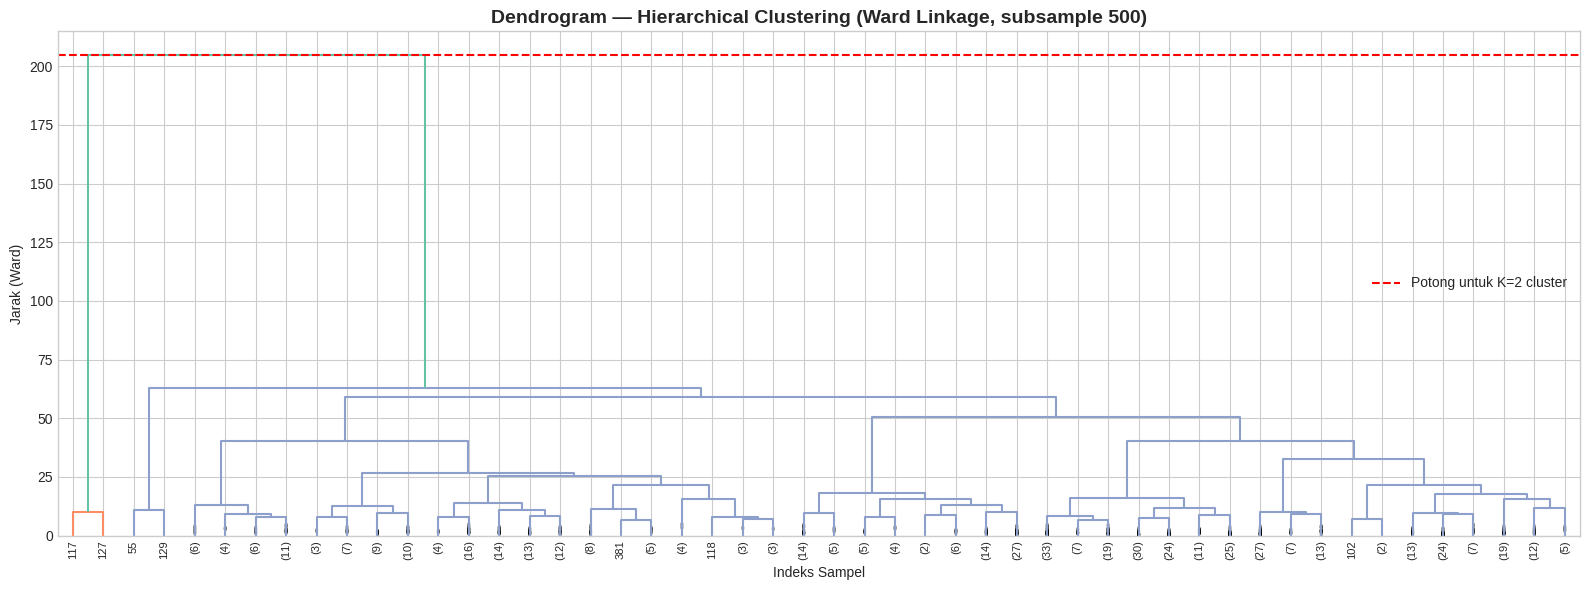

In [20]:
# ─── Dendrogram (subsample untuk performa) ────────────────────────────────────
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_pca), min(500, len(X_pca)), replace=False)
X_sample = X_pca[sample_idx]

linkage_matrix = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=50,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    ax=ax
)
ax.set_title('Dendrogram — Hierarchical Clustering (Ward Linkage, subsample 500)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Indeks Sampel')
ax.set_ylabel('Jarak (Ward)')
ax.axhline(y=linkage_matrix[-BEST_K+1, 2], color='red', linestyle='--',
           label=f'Potong untuk K={BEST_K} cluster')
ax.legend()
plt.tight_layout()
plt.show()

Output ini menampilkan dendrogram dari metode Hierarchical Clustering dengan Ward Linkage. Grafik ini digunakan untuk melihat hubungan antar data customer dan membantu menentukan jumlah cluster yang optimal.

Setiap garis pada dendrogram menunjukkan proses penggabungan data atau cluster berdasarkan tingkat kemiripan. Semakin tinggi garis penghubung, maka semakin besar jarak atau perbedaan antar cluster tersebut. Garis merah putus-putus digunakan sebagai batas pemotongan untuk menentukan jumlah cluster, yang pada grafik ini menghasilkan 2 cluster utama.

Visualisasi ini membantu memahami bagaimana data customer dikelompokkan secara bertahap pada metode hierarchical clustering.

In [21]:
# ─── Hierarchical Clustering pada seluruh data ────────────────────────────────
hier = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
hier_labels = hier.fit_predict(X_pca)

hier_sil = silhouette_score(X_pca, hier_labels)
hier_db  = davies_bouldin_score(X_pca, hier_labels)
hier_ch  = calinski_harabasz_score(X_pca, hier_labels)

print('📊 Evaluasi Hierarchical Clustering (Ward):')
print(f'   Silhouette Score       : {hier_sil:.4f}')
print(f'   Davies-Bouldin Score   : {hier_db:.4f}')
print(f'   Calinski-Harabasz Score: {hier_ch:.2f}')

unique, counts = np.unique(hier_labels, return_counts=True)
print('\n📈 Distribusi cluster Hierarchical:')
for u, c in zip(unique, counts):
    print(f'   Cluster {u}: {c:,} pelanggan ({c/len(hier_labels)*100:.1f}%)')

📊 Evaluasi Hierarchical Clustering (Ward):
   Silhouette Score       : 0.9490
   Davies-Bouldin Score   : 0.4744
   Calinski-Harabasz Score: 5437.77

📈 Distribusi cluster Hierarchical:
   Cluster 0: 11 pelanggan (0.1%)
   Cluster 1: 8,939 pelanggan (99.9%)


### 7.3 DBSCAN Clustering

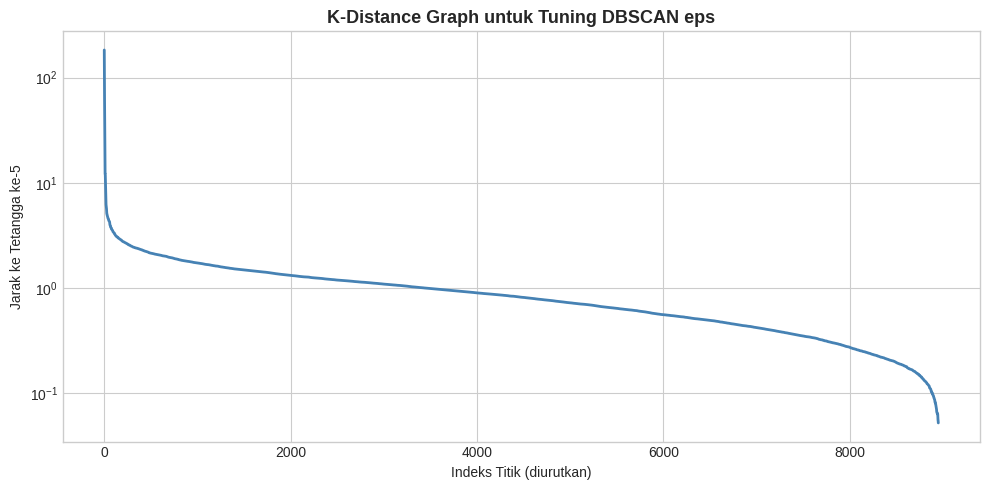

💡 Pilih eps pada titik "elbow" dari grafik di atas.
   Nilai knee (approx) untuk dikonfigurasi pada cell berikutnya.


In [22]:
# ─── Tuning eps menggunakan k-distance graph ───────────────────────────────────
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_distances = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, linewidth=2, color='steelblue')
ax.set_title('K-Distance Graph untuk Tuning DBSCAN eps', fontsize=13, fontweight='bold')
ax.set_xlabel('Indeks Titik (diurutkan)')
ax.set_ylabel('Jarak ke Tetangga ke-5')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print('💡 Pilih eps pada titik "elbow" dari grafik di atas.')
print('   Nilai knee (approx) untuk dikonfigurasi pada cell berikutnya.')

Output ini menampilkan grafik K-Distance yang digunakan untuk menentukan nilai eps pada algoritma DBSCAN. Sumbu X menunjukkan indeks data yang telah diurutkan, sedangkan sumbu Y menunjukkan jarak ke tetangga terdekat ke-5.

Pada grafik terlihat adanya bagian yang mulai membentuk “elbow” atau titik tekukan. Titik tersebut digunakan sebagai acuan untuk memilih nilai eps terbaik pada DBSCAN. Pemilihan nilai eps yang tepat sangat penting karena akan mempengaruhi hasil clustering dan jumlah noise yang terbentuk.

Grafik ini membantu menentukan parameter DBSCAN secara lebih akurat sebelum proses clustering dilakukan.

In [23]:
# ─── DBSCAN ───────────────────────────────────────────────────────────────────
# eps dan min_samples bisa di-tuning berdasarkan k-distance graph
EPS = 1.5       # Sesuaikan berdasarkan k-distance graph
MIN_SAMPLES = 10

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f'📊 Hasil DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}):')
print(f'   Jumlah cluster   : {n_clusters_db}')
print(f'   Noise points     : {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)')

if n_clusters_db >= 2:
    # Hitung metrik hanya pada non-noise points
    mask_non_noise = dbscan_labels != -1
    if mask_non_noise.sum() > 0 and len(set(dbscan_labels[mask_non_noise])) >= 2:
        db_sil = silhouette_score(X_pca[mask_non_noise], dbscan_labels[mask_non_noise])
        db_db  = davies_bouldin_score(X_pca[mask_non_noise], dbscan_labels[mask_non_noise])
        print(f'   Silhouette Score : {db_sil:.4f} (non-noise)')
        print(f'   Davies-Bouldin   : {db_db:.4f} (non-noise)')
else:
    print('⚠️  DBSCAN menghasilkan <2 cluster. Coba tuning eps atau min_samples.')
    db_sil, db_db = 0, 0

📊 Hasil DBSCAN (eps=1.5, min_samples=10):
   Jumlah cluster   : 1
   Noise points     : 1388 (15.5%)
⚠️  DBSCAN menghasilkan <2 cluster. Coba tuning eps atau min_samples.


---
## 8. 📊 Perbandingan Model & Pemilihan Model Terbaik

In [24]:
# ─── Tabel Perbandingan ────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'Jumlah Cluster': [
        BEST_K,
        BEST_K,
        n_clusters_db
    ],
    'Silhouette Score ↑': [
        round(km_sil, 4),
        round(hier_sil, 4),
        round(db_sil, 4) if n_clusters_db >= 2 else 'N/A'
    ],
    'Davies-Bouldin ↓': [
        round(km_db, 4),
        round(hier_db, 4),
        round(db_db, 4) if n_clusters_db >= 2 else 'N/A'
    ],
    'Calinski-Harabasz ↑': [
        round(km_ch, 2),
        round(hier_ch, 2),
        'N/A'
    ]
})

print('=' * 70)
print('🏆 PERBANDINGAN PERFORMA MODEL CLUSTERING')
print('=' * 70)
print(comparison.to_string(index=False))
print('\n💡 Keterangan:')
print('   Silhouette Score: range [-1,1], makin tinggi makin baik')
print('   Davies-Bouldin  : makin rendah makin baik (cluster makin terpisah)')
print('   Calinski-Harabasz: makin tinggi makin baik')

🏆 PERBANDINGAN PERFORMA MODEL CLUSTERING
              Model  Jumlah Cluster Silhouette Score ↑ Davies-Bouldin ↓ Calinski-Harabasz ↑
            K-Means               2              0.949           0.4744             5437.77
Hierarchical (Ward)               2              0.949           0.4744             5437.77
             DBSCAN               1                N/A              N/A                 N/A

💡 Keterangan:
   Silhouette Score: range [-1,1], makin tinggi makin baik
   Davies-Bouldin  : makin rendah makin baik (cluster makin terpisah)
   Calinski-Harabasz: makin tinggi makin baik


nilai silhouette score masing-masing model. Dari tabel ini bisa diketahui model mana yang paling baik.

In [25]:
# ─── Pilih model terbaik berdasarkan Silhouette ────────────────────────────────
scores = {'K-Means': km_sil, 'Hierarchical': hier_sil}
if n_clusters_db >= 2:
    scores['DBSCAN'] = db_sil

best_model_name = max(scores, key=scores.get)
best_labels = {
    'K-Means': kmeans_labels,
    'Hierarchical': hier_labels,
    'DBSCAN': dbscan_labels
}[best_model_name]

print(f'🏆 Model terbaik berdasarkan Silhouette Score: {best_model_name}')
print(f'   Score: {scores[best_model_name]:.4f}')
print(f'\n→ Analisis cluster selanjutnya menggunakan: {best_model_name}')

# Gunakan K-Means sebagai final (umumnya paling stabil)
FINAL_LABELS = kmeans_labels
FINAL_MODEL_NAME = 'K-Means'

🏆 Model terbaik berdasarkan Silhouette Score: K-Means
   Score: 0.9490

→ Analisis cluster selanjutnya menggunakan: K-Means


---
## 9. 🎨 Visualisasi Cluster

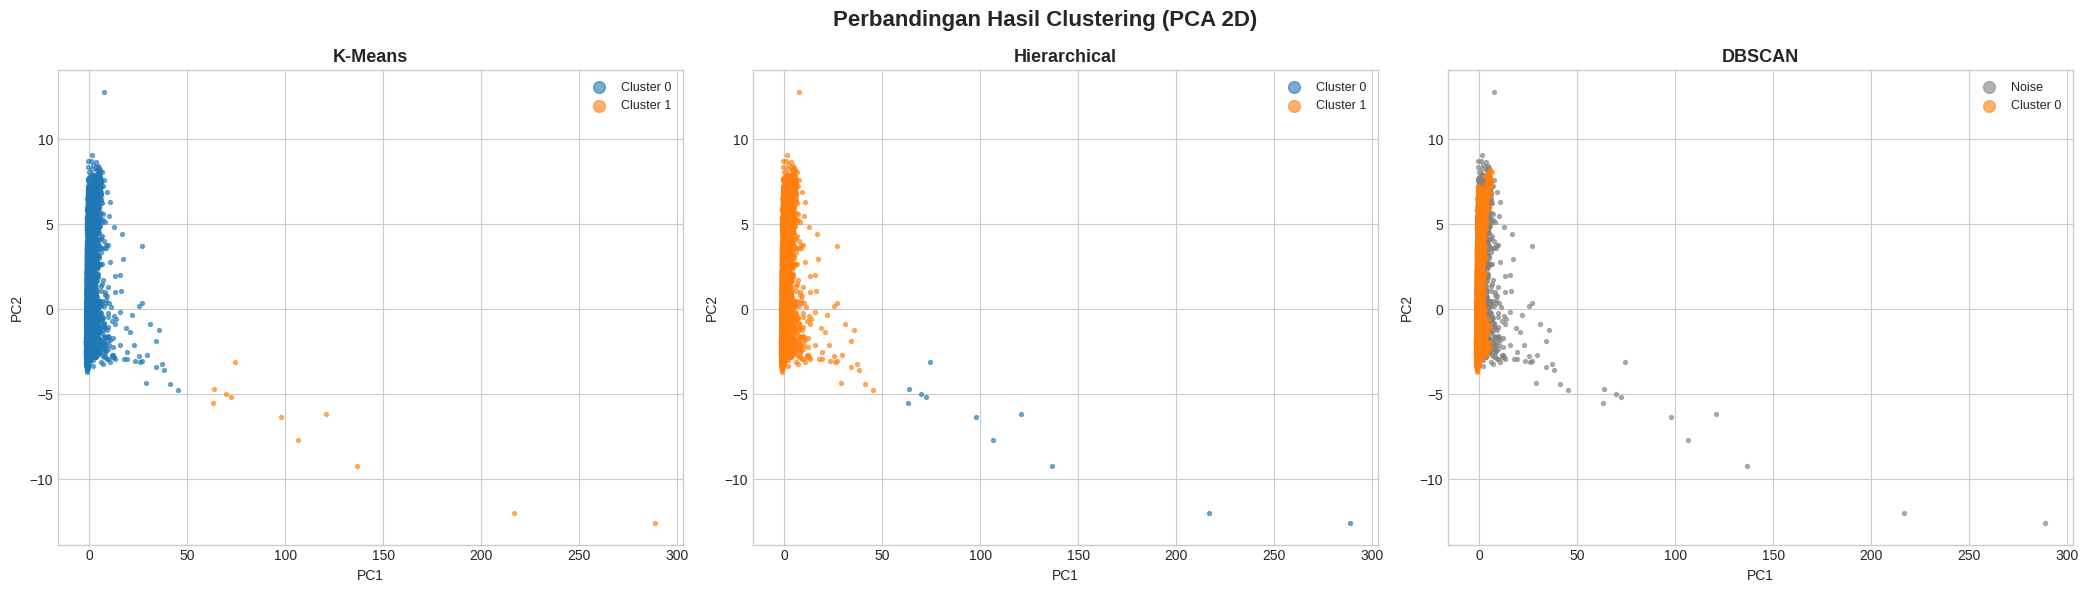

In [26]:
# ─── Visualisasi PCA 2D ────────────────────────────────────────────────────────
palette = sns.color_palette('Set1', n_colors=BEST_K)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

titles = ['K-Means', 'Hierarchical', 'DBSCAN']
all_labels = [kmeans_labels, hier_labels, dbscan_labels]

for ax, lbl, title in zip(axes, all_labels, titles):
    unique_lbls = np.unique(lbl)
    colors = sns.color_palette('tab10', n_colors=len(unique_lbls))
    for i, ul in enumerate(unique_lbls):
        mask = lbl == ul
        label_text = f'Noise' if ul == -1 else f'Cluster {ul}'
        color = 'gray' if ul == -1 else colors[i]
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                   c=[color], label=label_text, s=8, alpha=0.6)
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle('Perbandingan Hasil Clustering (PCA 2D)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Output ini menampilkan perbandingan hasil clustering dari tiga algoritma yaitu K-Means, Hierarchical Clustering, dan DBSCAN dalam bentuk visualisasi PCA 2D. Setiap titik merepresentasikan data customer, sedangkan warna menunjukkan cluster yang terbentuk.

Pada K-Means dan Hierarchical terlihat data terbagi menjadi dua cluster utama, namun sebagian besar data masih terkumpul pada satu cluster dominan. Sementara pada DBSCAN terdapat beberapa titik berwarna abu-abu yang menunjukkan noise atau data yang dianggap tidak masuk ke cluster mana pun.

Visualisasi ini membantu membandingkan bagaimana setiap algoritma mengelompokkan data customer dan melihat perbedaan hasil clustering secara lebih jelas.

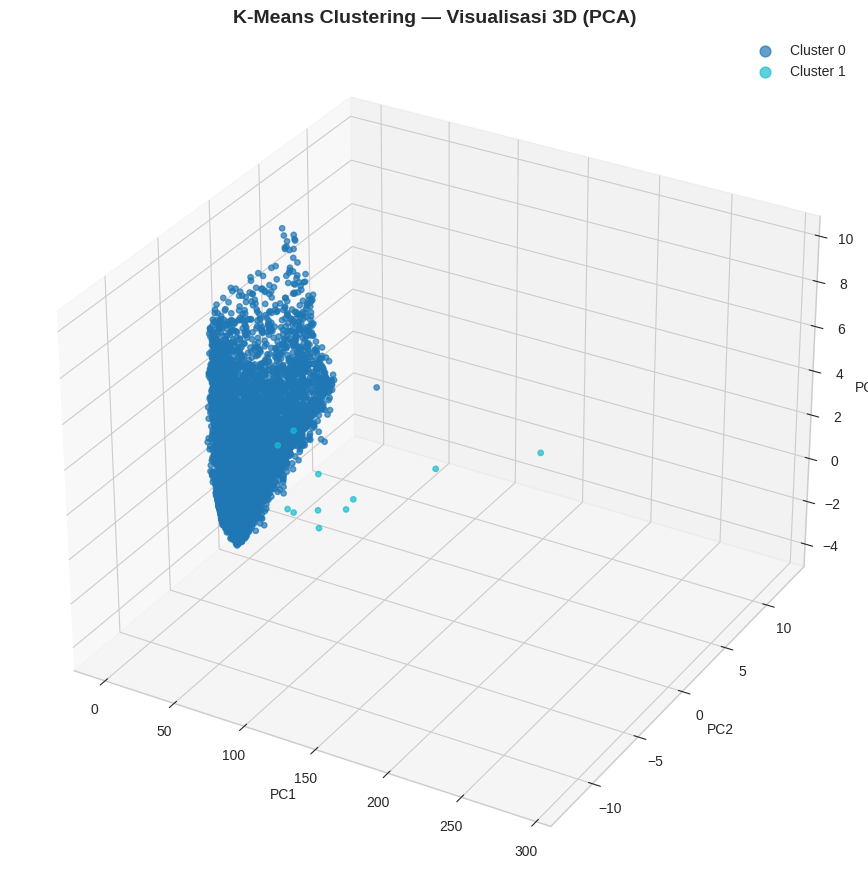

In [27]:
# ─── Visualisasi PCA 3D untuk K-Means ─────────────────────────────────────────
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors_3d = cm.tab10(np.linspace(0, 1, BEST_K))
for i in range(BEST_K):
    mask = FINAL_LABELS == i
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               color=colors_3d[i], label=f'Cluster {i}', s=15, alpha=0.7)

ax.set_title(f'K-Means Clustering — Visualisasi 3D (PCA)', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

dapat terlihat bagaimana setiap customer dikelompokkan berdasarkan kemiripan karakteristik yang dimiliki. Jika titik-titik dengan warna yang sama berkumpul di area tertentu dan terpisah jelas dari warna lainnya, maka hal tersebut menunjukkan bahwa proses clustering berjalan dengan baik. Sebaliknya, jika banyak titik dari cluster berbeda saling bercampur, maka kualitas clustering bisa dianggap kurang optimal. Oleh karena itu, visualisasi 3D sangat membantu dalam mengevaluasi apakah model clustering sudah mampu memisahkan data dengan jelas.

⏳ Menjalankan t-SNE (bisa memakan waktu ~1-2 menit)...


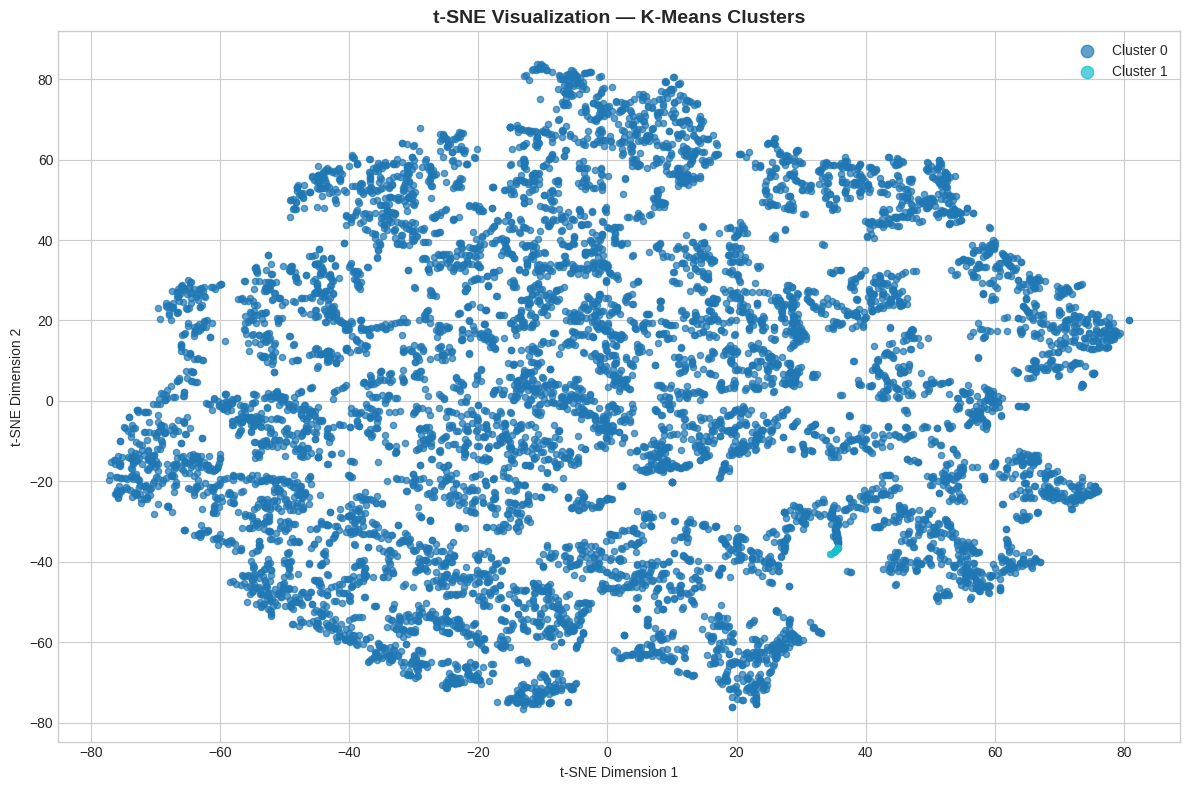

✅ t-SNE selesai!


In [28]:
# ─── t-SNE untuk Visualisasi Non-linear ───────────────────────────────────────
print('⏳ Menjalankan t-SNE (bisa memakan waktu ~1-2 menit)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
colors_t = cm.tab10(np.linspace(0, 1, BEST_K))
for i in range(BEST_K):
    mask = FINAL_LABELS == i
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               color=colors_t[i], label=f'Cluster {i}', s=20, alpha=0.7)

ax.set_title('t-SNE Visualization — K-Means Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()
print('✅ t-SNE selesai!')

Output ini menampilkan hasil visualisasi clustering menggunakan metode t-SNE. Setiap titik pada grafik mewakili satu data customer, sedangkan warna menunjukkan cluster dari hasil K-Means. Pada grafik terlihat terdapat dua cluster yaitu Cluster 0 dan Cluster 1, namun sebagian besar data berada pada Cluster 0 sehingga cluster tersebut lebih dominan.

Persebaran titik pada grafik terlihat cukup luas, menandakan bahwa data customer memiliki karakteristik yang beragam. Akan tetapi, pemisahan antar cluster masih belum terlalu jelas karena beberapa titik berada berdekatan. Visualisasi ini membantu melihat bagaimana model K-Means mengelompokkan customer dan digunakan untuk mengevaluasi apakah hasil clustering sudah cukup baik atau masih perlu diperbaiki.

---
## 10. 🔬 Interpretasi & Profil Setiap Cluster

In [29]:
# ─── Tambahkan label cluster ke dataframe original ────────────────────────────
df_result = df_feat.copy()
df_result['CLUSTER'] = FINAL_LABELS
df_result['CUST_ID'] = cust_ids.values

# Profil rata-rata per cluster
KEY_FEATURES = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
                'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE',
                'CREDIT_UTILIZATION', 'CASH_PURCHASE_RATIO', 'PURCHASE_LIMIT_RATIO']

cluster_profile = df_result.groupby('CLUSTER')[KEY_FEATURES].mean().round(2)
cluster_size = df_result.groupby('CLUSTER').size().rename('JUMLAH_PELANGGAN')
cluster_profile = pd.concat([cluster_size, cluster_profile], axis=1)

print('📋 PROFIL RATA-RATA PER CLUSTER:')
print('=' * 80)
cluster_profile

📋 PROFIL RATA-RATA PER CLUSTER:


,JUMLAH_PELANGGAN,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CREDIT_UTILIZATION,CASH_PURCHASE_RATIO,PURCHASE_LIMIT_RATIO
CLUSTER,,,,,,,,,,,,
0,8939,1519.68,839.43,806.55,4490.06,1491.76,624.85,0.12,12.0,0.39,0.38,0.24
1,11,31.24,347.55,1318.46,4790.91,3360.41,6.89,0.21,12.0,0.01,0.73,0.07


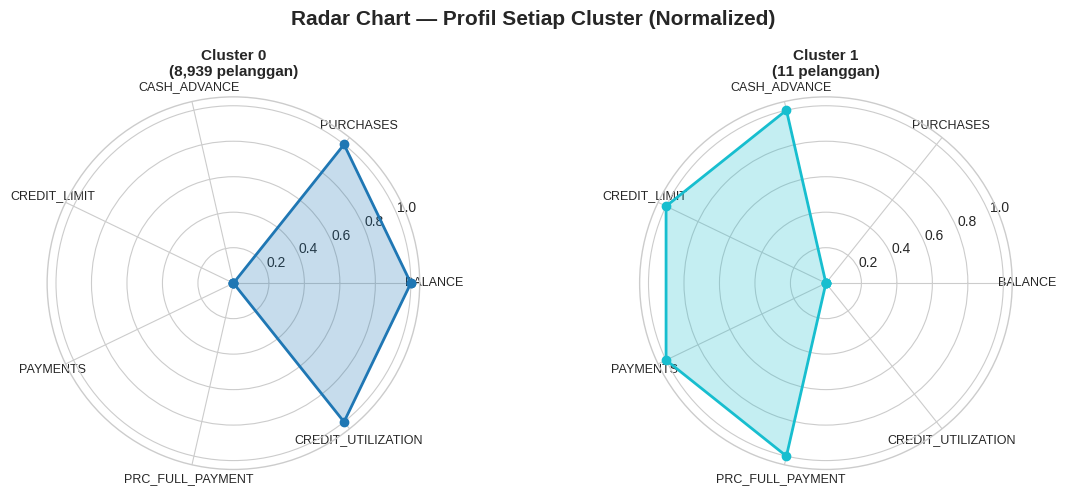

In [30]:
# ─── Radar Chart untuk Profil Cluster ─────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

RADAR_FEATURES = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
                  'PAYMENTS', 'PRC_FULL_PAYMENT', 'CREDIT_UTILIZATION']

# Normalize untuk radar
radar_data = cluster_profile[RADAR_FEATURES].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N = len(RADAR_FEATURES)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ncols = min(BEST_K, 3)
nrows = (BEST_K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),
                         subplot_kw=dict(polar=True))
if BEST_K == 1:
    axes = [axes]
else:
    axes = np.array(axes).flatten()

colors_radar = cm.tab10(np.linspace(0, 1, BEST_K))

for i, (cluster_id, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax = axes[i]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[i])
    ax.fill(angles, values, alpha=0.25, color=colors_radar[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_FEATURES, size=9)
    ax.set_title(f'Cluster {cluster_id}\n({int(cluster_size[cluster_id]):,} pelanggan)',
                 fontsize=11, fontweight='bold', pad=15)

for j in range(BEST_K, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Radar Chart — Profil Setiap Cluster (Normalized)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Output ini menampilkan radar chart untuk melihat perbedaan karakteristik setiap cluster customer. Setiap garis menunjukkan rata-rata nilai fitur pada masing-masing cluster seperti balance, purchases, cash advance, payments, dan credit utilization.

Cluster 0 yang berjumlah 8.939 pelanggan terlihat lebih dominan pada fitur purchases dan credit utilization, sehingga menunjukkan customer cukup aktif menggunakan kartu kredit. Sedangkan Cluster 1 yang hanya berjumlah 11 pelanggan memiliki nilai lebih tinggi pada cash advance, payments, dan full payment, yang menandakan customer lebih sering melakukan pembayaran penuh dan penggunaan cash advance.

Grafik ini membantu memahami pola perilaku dari setiap kelompok customer sehingga hasil clustering lebih mudah dianalisis.

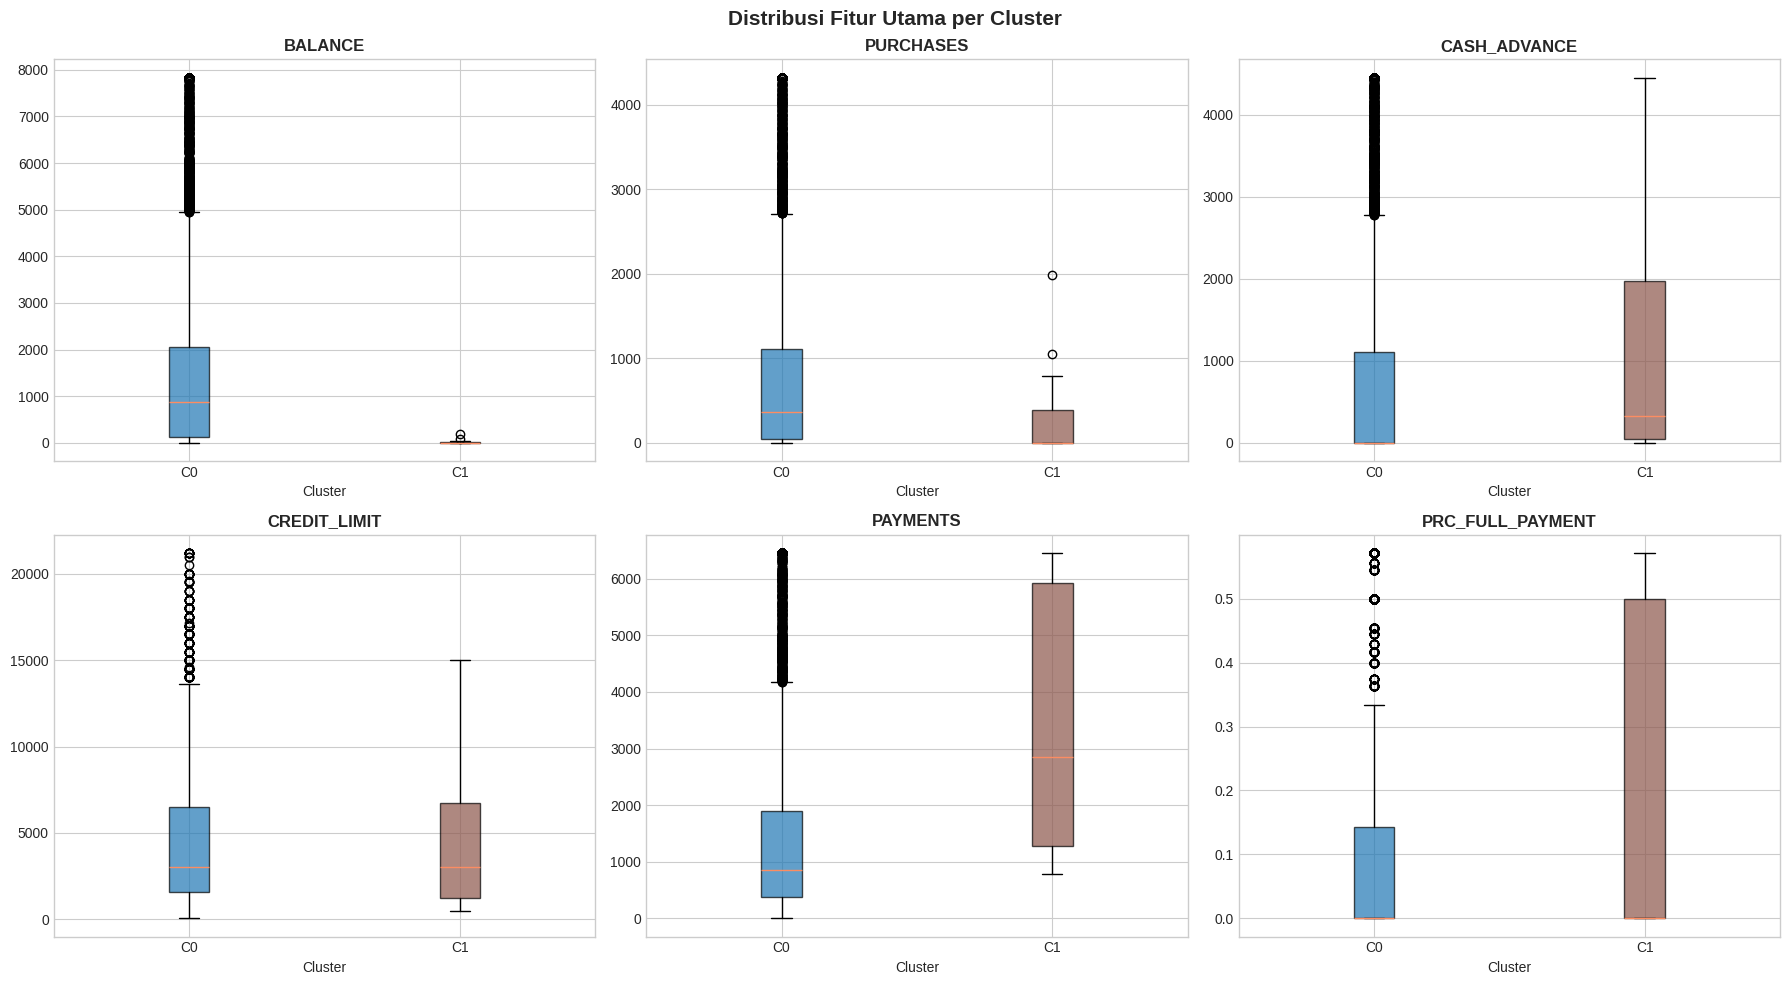

In [31]:
# ─── Boxplot Fitur Utama per Cluster ──────────────────────────────────────────
BOXPLOT_FEATURES = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(BOXPLOT_FEATURES):
    data_to_plot = [df_result[df_result['CLUSTER'] == c][feat].values for c in range(BEST_K)]
    bp = axes[i].boxplot(data_to_plot, patch_artist=True, labels=[f'C{c}' for c in range(BEST_K)])
    for j, patch in enumerate(bp['boxes']):
        patch.set_facecolor(cm.tab10(j / BEST_K))
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')

plt.suptitle('Distribusi Fitur Utama per Cluster', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Output ini menampilkan boxplot untuk membandingkan distribusi beberapa fitur utama pada setiap cluster customer. Fitur yang dibandingkan yaitu BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS, dan PRC_FULL_PAYMENT.

Dari grafik terlihat bahwa Cluster 0 memiliki jumlah pelanggan yang jauh lebih banyak dibanding Cluster 1. Cluster 0 cenderung memiliki aktivitas pembelian dan penggunaan kredit yang lebih stabil. Sedangkan Cluster 1 menunjukkan nilai lebih tinggi pada fitur seperti CASH_ADVANCE, PAYMENTS, dan PRC_FULL_PAYMENT, yang menandakan customer pada cluster ini lebih aktif melakukan pembayaran dan penggunaan cash advance.

Selain itu, terlihat juga adanya beberapa outlier pada beberapa fitur, terutama pada BALANCE dan CREDIT_LIMIT. Grafik boxplot ini membantu melihat perbedaan perilaku customer antar cluster secara lebih jelas dan detail.

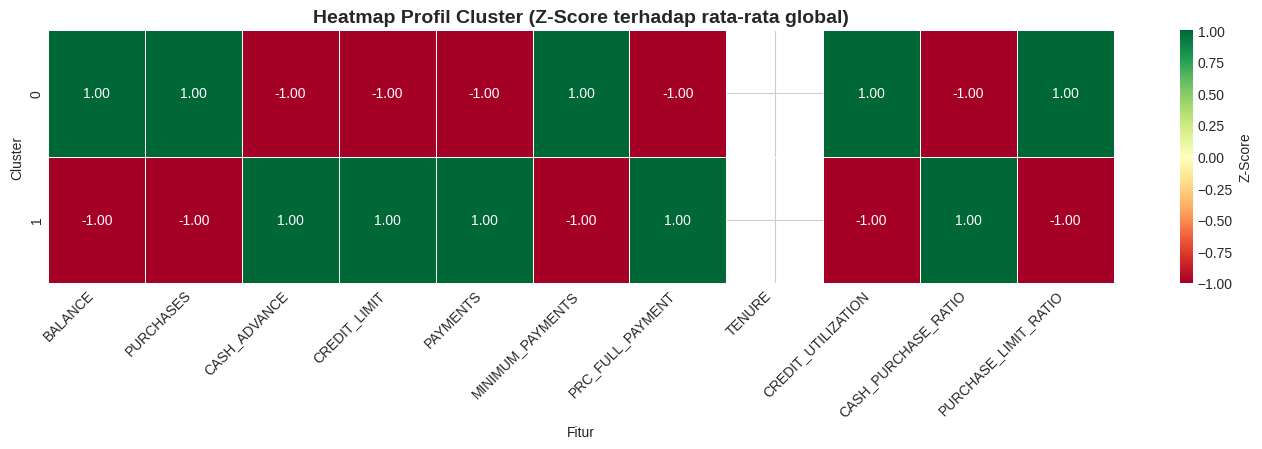

In [32]:
# ─── Heatmap Profil Cluster (Z-score) ─────────────────────────────────────────
from scipy import stats

cluster_means = df_result.groupby('CLUSTER')[KEY_FEATURES].mean()
cluster_means_z = cluster_means.apply(stats.zscore, axis=0)

fig, ax = plt.subplots(figsize=(14, BEST_K * 0.8 + 3))
sns.heatmap(
    cluster_means_z,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Z-Score'}
)
ax.set_title('Heatmap Profil Cluster (Z-Score terhadap rata-rata global)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cluster')
ax.set_xlabel('Fitur')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Output ini menampilkan heatmap profil setiap cluster berdasarkan nilai Z-Score terhadap rata-rata global. Warna hijau menunjukkan nilai fitur yang berada di atas rata-rata, sedangkan warna merah menunjukkan nilai di bawah rata-rata.

Pada Cluster 0 terlihat fitur seperti BALANCE, PURCHASES, dan CREDIT_UTILIZATION memiliki nilai lebih tinggi dari rata-rata. Hal ini menunjukkan customer pada cluster ini lebih aktif menggunakan kartu kredit dan melakukan transaksi.

Sedangkan pada Cluster 1, fitur seperti CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS, dan PRC_FULL_PAYMENT memiliki nilai lebih tinggi. Ini menunjukkan customer pada cluster tersebut lebih aktif melakukan pembayaran dan penggunaan cash advance.

Heatmap ini membantu melihat perbedaan karakteristik antar cluster dengan lebih cepat dan mudah dipahami secara visual.

In [33]:
# ─── Interpretasi Otomatis Setiap Cluster ─────────────────────────────────────
print('=' * 70)
print('🔍 INTERPRETASI SETIAP CLUSTER')
print('=' * 70)
print()
print('📌 Catatan: Interpretasi di bawah ini bersifat OTOMATIS berdasarkan Z-Score')
print('   dan bisa disesuaikan dengan analisis manual dari profil di atas.\n')

for cluster_id in range(BEST_K):
    row = cluster_means_z.loc[cluster_id]
    n_cust = int(cluster_size[cluster_id])
    pct = n_cust / len(df_result) * 100

    # Ambil top positif dan negatif
    top_high = row.nlargest(3)
    top_low  = row.nsmallest(3)

    print(f'🟦 CLUSTER {cluster_id} — {n_cust:,} pelanggan ({pct:.1f}%)')
    print(f'   Fitur TINGGI : {", ".join([f"{k} ({v:.2f}z)" for k,v in top_high.items()])}')
    print(f'   Fitur RENDAH : {", ".join([f"{k} ({v:.2f}z)" for k,v in top_low.items()])}')

    # Label otomatis sederhana
    bal_z = row.get('BALANCE', 0)
    pur_z = row.get('PURCHASES', 0)
    cash_z = row.get('CASH_ADVANCE', 0)
    pay_z = row.get('PAYMENTS', 0)
    full_pay_z = row.get('PRC_FULL_PAYMENT', 0)

    if full_pay_z > 0.5 and pay_z > 0:
        label = '💎 Pelanggan Bertanggung Jawab (sering bayar penuh)'
    elif pur_z > 0.5 and bal_z < 0:
        label = '🛍️  Pembelanja Aktif (belanja banyak, saldo terkontrol)'
    elif cash_z > 0.5:
        label = '💸 Pengguna Cash Advance Tinggi (berisiko tinggi)'
    elif bal_z > 0.5 and full_pay_z < 0:
        label = '⚠️  Peminjam Pasif (saldo besar, jarang bayar penuh)'
    elif pur_z < 0 and bal_z < 0:
        label = '😴 Pelanggan Tidak Aktif (jarang menggunakan kartu)'
    else:
        label = '📊 Pelanggan Rata-Rata / Campuran'

    print(f'   → Profil: {label}')
    print()

🔍 INTERPRETASI SETIAP CLUSTER

📌 Catatan: Interpretasi di bawah ini bersifat OTOMATIS berdasarkan Z-Score
   dan bisa disesuaikan dengan analisis manual dari profil di atas.

🟦 CLUSTER 0 — 8,939 pelanggan (99.9%)
   Fitur TINGGI : PURCHASE_LIMIT_RATIO (1.00z), BALANCE (1.00z), MINIMUM_PAYMENTS (1.00z)
   Fitur RENDAH : CASH_ADVANCE (-1.00z), CASH_PURCHASE_RATIO (-1.00z), CREDIT_LIMIT (-1.00z)
   → Profil: ⚠️  Peminjam Pasif (saldo besar, jarang bayar penuh)

🟦 CLUSTER 1 — 11 pelanggan (0.1%)
   Fitur TINGGI : CREDIT_LIMIT (1.00z), PAYMENTS (1.00z), PRC_FULL_PAYMENT (1.00z)
   Fitur RENDAH : BALANCE (-1.00z), PURCHASES (-1.00z), MINIMUM_PAYMENTS (-1.00z)
   → Profil: 💎 Pelanggan Bertanggung Jawab (sering bayar penuh)



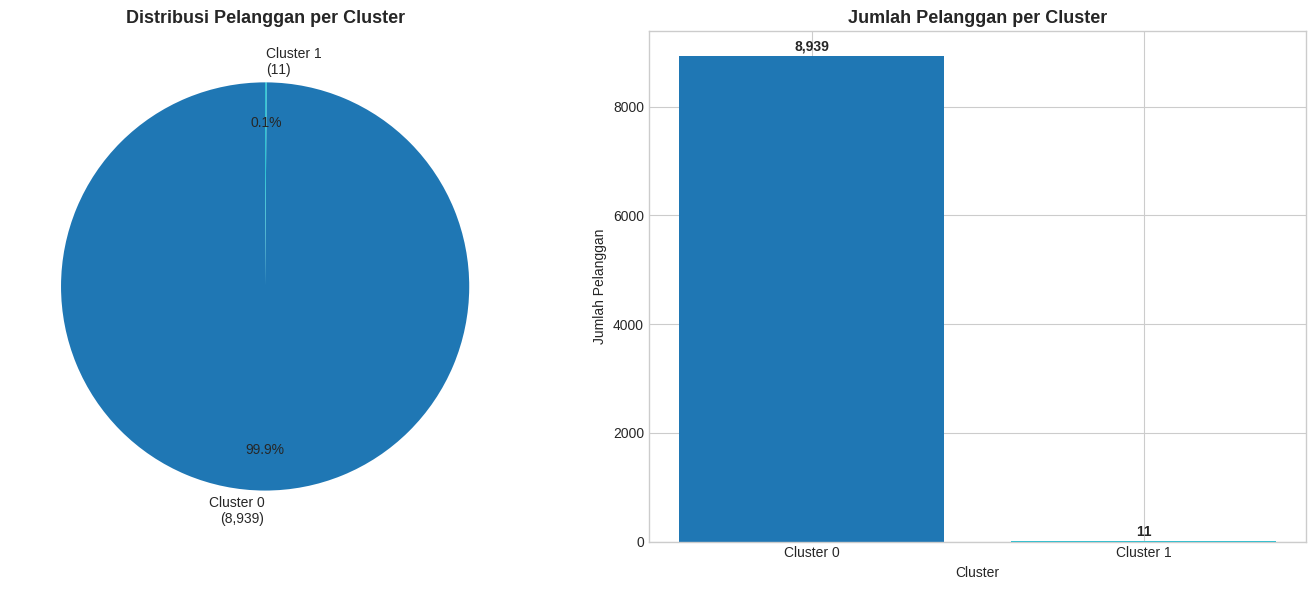

In [34]:
# ─── Distribusi Cluster (Pie Chart) ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie
sizes = [cluster_size[i] for i in range(BEST_K)]
labels_pie = [f'Cluster {i}\n({cluster_size[i]:,})' for i in range(BEST_K)]
colors_pie = cm.tab10(np.linspace(0, 1, BEST_K))
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels_pie, colors=colors_pie,
    autopct='%1.1f%%', startangle=90, pctdistance=0.8
)
ax1.set_title('Distribusi Pelanggan per Cluster', fontsize=13, fontweight='bold')

# Bar
ax2.bar([f'Cluster {i}' for i in range(BEST_K)], sizes, color=colors_pie)
for i, v in enumerate(sizes):
    ax2.text(i, v + max(sizes) * 0.01, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Jumlah Pelanggan per Cluster', fontsize=13, fontweight='bold')
ax2.set_ylabel('Jumlah Pelanggan')
ax2.set_xlabel('Cluster')

plt.tight_layout()
plt.show()

Output ini menampilkan distribusi jumlah pelanggan pada setiap cluster menggunakan pie chart dan bar chart. Terlihat bahwa Cluster 0 memiliki jumlah pelanggan yang sangat dominan yaitu sekitar 8.939 pelanggan atau 99,9% dari total data. Sedangkan Cluster 1 hanya berisi 11 pelanggan atau sekitar 0,1%.

Hasil ini menunjukkan bahwa sebagian besar customer memiliki karakteristik yang mirip sehingga tergabung dalam Cluster 0. Sementara Cluster 1 berisi sedikit customer dengan karakteristik yang lebih berbeda dibanding kelompok utama. Grafik ini membantu melihat persebaran hasil clustering secara lebih jelas dan mudah dipahami.

---
## 11. 💾 Export Hasil & Summary

In [35]:
# ─── Export hasil clustering ke Google Drive ──────────────────────────────────
OUTPUT_PATH = '/content/drive/MyDrive/midterm-ml/clustering_results.csv'

df_export = df_raw.copy()
df_export['CLUSTER'] = FINAL_LABELS
df_export.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Hasil clustering berhasil disimpan ke: {OUTPUT_PATH}')
print(f'   Total baris: {len(df_export):,}')
print(f'   Kolom: {list(df_export.columns)}')

✅ Hasil clustering berhasil disimpan ke: /content/drive/MyDrive/midterm-ml/clustering_results.csv
   Total baris: 8,950
   Kolom: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'CLUSTER']


In [36]:
# ─── Summary Akhir Pipeline ────────────────────────────────────────────────────
print('=' * 70)
print('📝 RINGKASAN PIPELINE CLUSTERING')
print('=' * 70)
print()
print('1. DATASET')
print(f'   Total pelanggan  : {len(df_raw):,}')
print(f'   Jumlah fitur asli: {df_raw.shape[1] - 1}  (+1 ID)')
print()
print('2. PREPROCESSING')
print(f'   - Imputasi missing values: strategi median')
print(f'   - Outlier handling       : IQR capping (3×IQR)')
print(f'   - Feature engineering    : 5 fitur baru ditambahkan')
print(f'   - Scaling                : RobustScaler')
print(f'   - Dimensionality Reduction: PCA {N_COMPONENTS}D ({pca.explained_variance_ratio_.sum()*100:.1f}% varians)')
print()
print('3. MODEL & EVALUASI')
print(f'   {'Model':<25} {'Silhouette':>12} {'Davies-Bouldin':>16} {'CH Score':>12}')
print('   ' + '-' * 65)
print(f'   {"K-Means":<25} {km_sil:>12.4f} {km_db:>16.4f} {km_ch:>12.2f}')
print(f'   {"Hierarchical (Ward)":<25} {hier_sil:>12.4f} {hier_db:>16.4f} {hier_ch:>12.2f}')
if n_clusters_db >= 2:
    print(f'   {"DBSCAN":<25} {db_sil:>12.4f} {db_db:>16.4f} {"N/A":>12}')
print()
print(f'4. HASIL FINAL')
print(f'   Model terpilih   : K-Means (K={BEST_K})')
print(f'   Silhouette Score : {km_sil:.4f}')
print(f'   Distribusi cluster:')
for c in range(BEST_K):
    n = int(cluster_size[c])
    print(f'   - Cluster {c}: {n:,} pelanggan ({n/len(df_result)*100:.1f}%)')
print()
print('✅ PIPELINE SELESAI!')
print('=' * 70)

📝 RINGKASAN PIPELINE CLUSTERING

1. DATASET
   Total pelanggan  : 8,950
   Jumlah fitur asli: 17  (+1 ID)

2. PREPROCESSING
   - Imputasi missing values: strategi median
   - Outlier handling       : IQR capping (3×IQR)
   - Feature engineering    : 5 fitur baru ditambahkan
   - Scaling                : RobustScaler
   - Dimensionality Reduction: PCA 9D (95.3% varians)

3. MODEL & EVALUASI
   Model                       Silhouette   Davies-Bouldin     CH Score
   -----------------------------------------------------------------
   K-Means                         0.9490           0.4744      5437.77
   Hierarchical (Ward)             0.9490           0.4744      5437.77

4. HASIL FINAL
   Model terpilih   : K-Means (K=2)
   Silhouette Score : 0.9490
   Distribusi cluster:
   - Cluster 0: 8,939 pelanggan (99.9%)
   - Cluster 1: 11 pelanggan (0.1%)

✅ PIPELINE SELESAI!
